# 📚 Agronomy Publications — Exploratory Data Analysis
**Source:** OpenAlex API (`pyalex`)  
**Scope:** Key agronomists and their co-authors · 2020–2025  
**Goal:** Understand what the data contains, explore citation patterns, journal reach, concept coverage, and temporal trends — without any topic modeling yet.

---
**Sections**
1. Setup & Data Collection  
2. Raw API Response Structure  
3. Building the Publications DataFrame  
4. Citation Analysis  
5. Author & Authorship Analysis  
6. Journal & Publisher Analysis  
7. Concept & Topic Tag Analysis  
8. Temporal Trends  
9. Co-authorship Network Overview

---
## 1. Setup & Data Collection

In [440]:
from pyalex import Works, Authors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
import time
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

In [441]:
# ── Primary authors of interest ────────────────────────────────────────────────
author_ids = {
    "https://openalex.org/A5064124035": "Ciampitti",
    "https://openalex.org/A5074248754": "Basso",
    "https://openalex.org/A5053935458": "Kaiyu",
    "https://openalex.org/A5005128316": "Grassini",
    "https://openalex.org/A5010412338": "Archontoulis",
    "https://openalex.org/A5073947803": "Castellano",
    "https://openalex.org/A5026642372": "Lobell",
    "https://openalex.org/A5073721257": "Peng",
    "https://openalex.org/A5050045466": "Vara Prasad",
    "https://openalex.org/A5072153127": "Rattalino",
    "https://openalex.org/A5047677277": "Hoogenboom",
}
coauthors_ids = {}

def get_works(author_ids_dict, from_date="2020-01-01", to_date="2025-12-31"):
    """Fetch all works for a dict of {openalex_id: name}, enriching each work
    with queried_author, queried_author_id, author_position, and
    is_corresponding_author."""
    works_list = []
    for aid, name in author_ids_dict.items():
        print(f"  Fetching: {name} …", end=" ")
        cursor = "*"
        n = 0
        while cursor:
            results = (
                Works()
                .filter(**{
                    "author.id": aid,
                    "from_publication_date": from_date,
                    "to_publication_date": to_date,
                })
                .get(per_page=200, cursor=cursor)
            )
            for work in results:
                author_position, is_corresponding = None, False
                for auth in work.get("authorships", []):
                    if auth.get("author", {}).get("id") == aid:
                        author_position = auth.get("author_position")
                        is_corresponding = auth.get("is_corresponding", False)
                        break
                work["queried_author"] = name
                work["queried_author_id"] = aid
                work["author_position"] = author_position
                work["is_corresponding_author"] = is_corresponding
                works_list.append(work)
                n += 1
            next_cursor = results.meta.get("next_cursor")
            cursor = next_cursor if next_cursor != cursor else None
            time.sleep(0.5)
    print(f"\nTotal works fetched: {len(works_list)}")
    return works_list


def get_prolific_coauthors(primary_works, author_ids, coauthors_ids, top_n=15):
    """
    Return {author_id: name} for the top_n most frequent co-authors,
    excluding anyone already in author_ids or coauthors_ids.
    Also updates both author_ids and coauthors_ids in-place with the new entries.
    """
    already_tracked = set(author_ids.keys()) | set(coauthors_ids.keys())

    counter = Counter()
    for work in primary_works:
        qid = work.get("queried_author_id")
        for auth in work.get("authorships", []):
            aid  = auth.get("author", {}).get("id")
            name = auth.get("author", {}).get("display_name")
            # Skip if same as the queried author or already in either list
            if aid and aid != qid and aid not in already_tracked:
                counter[(aid, name)] += 1

    top = counter.most_common(top_n)
    new_coauthors = {}
    for (aid, name), cnt in top:
        print(f"  {name}: {cnt} shared papers")
        new_coauthors[aid] = name

    # Add to both lists
    coauthors_ids.update(new_coauthors)
    author_ids.update(new_coauthors)

    return new_coauthors


In [385]:

# ── Fetch data  (runs once; ~2-5 min depending on API speed) ──────────────────
print("=== Primary authors ===")
primary_works = get_works(author_ids)

print("\n=== Identifying top co-authors ===")
coauthors_ids = get_prolific_coauthors(primary_works, author_ids, coauthors_ids, top_n=15)

print("\n=== Co-authors ===")
coauthors_works = get_works(coauthors_ids)

# ── Tag each raw work with its author_type ─────────────────────────────────────
for w in primary_works:
    w["author_type"] = "Primary"
for w in coauthors_works:
    w["author_type"] = "Collaborator"

# ── Combine into a single list (no duplicate API calls) ───────────────────────
all_works = primary_works + coauthors_works

print(f"\nPrimary works   : {len(primary_works)}")
print(f"Coauthor works  : {len(coauthors_works)}")
print(f"Total combined  : {len(all_works)}")


=== Primary authors ===
  Fetching: Ciampitti …   Fetching: Basso …   Fetching: Kaiyu …   Fetching: Grassini …   Fetching: Archontoulis …   Fetching: Castellano …   Fetching: Lobell …   Fetching: Peng …   Fetching: Vara Prasad …   Fetching: Rattalino …   Fetching: Hoogenboom … 
Total works fetched: 1844

=== Identifying top co-authors ===
  Wang Zhou: 100 shared papers
  Zhenong Jin: 87 shared papers
  Kenneth J. Boote: 83 shared papers
  Chongya Jiang: 76 shared papers
  Ana Julia Paula Carcedo: 71 shared papers
  Vakhtang Shelia: 70 shared papers
  Senthold Asseng: 67 shared papers
  Jinyun Tang: 66 shared papers
  Thomas Gaiser: 65 shared papers
  Sheng Wang: 64 shared papers
  Benjamin Dumont: 63 shared papers
  Amit Kumar Srivastava: 59 shared papers
  R. F. Grant: 57 shared papers
  Heidi Webber: 56 shared papers
  Tobias K. D. Weber: 56 shared papers

=== Co-authors ===
  Fetching: Wang Zhou …   Fetching: Zhenong Jin …   Fetching: Kenneth J. Boote …   Fetching: Chongya Jiang …  

---
## 2. Exploring the Raw API Response Structure
Before building DataFrames, let's inspect a single work object to understand what OpenAlex provides.  
Each field is documented at https://docs.openalex.org/api-entities/works.

In [442]:
#| include: false

# ── Summary table: field coverage across ALL works ────────────────────
field_presence = {}
for work in all_works:
    for k, v in work.items():
        is_present = v is not None and v != [] and v != {}
        field_presence.setdefault(k, 0)
        if is_present:
            field_presence[k] += 1

total = len(all_works)
coverage = (
    pd.DataFrame.from_dict(field_presence, orient="index", columns=["present"])
    .assign(pct=lambda d: (d["present"] / total * 100).round(1))
    .sort_values("pct", ascending=False)
    .reset_index()
    .rename(columns={"index": "field"})
)

print(f"Field coverage across {total} works:\n")
print(coverage.to_string(index=False))


Field coverage across 3412 works:

                         field  present   pct
                            id     3412 100.0
                         title     3412 100.0
              publication_year     3412 100.0
                  display_name     3412 100.0
              publication_date     3412 100.0
                           ids     3412 100.0
                   authorships     3412 100.0
              primary_location     3412 100.0
                          type     3412 100.0
                   open_access     3412 100.0
   institutions_distinct_count     3412 100.0
                  has_fulltext     3412 100.0
      countries_distinct_count     3412 100.0
                  updated_date     3412 100.0
                   author_type     3412 100.0
               locations_count     3412 100.0
                     locations     3412 100.0
                       is_xpac     3412 100.0
                  is_retracted     3412 100.0
                   is_paratext     3412 100.0

---
## 3. Building the Publications DataFrame

In [443]:
def get_publications_table(works_list):
    """
    Flatten raw OpenAlex works into a tidy DataFrame.
    Extracts only fields present in needed_cols, keeping display names
    and counts while dropping IDs, URLs, and scores.
    """
    rows = []
    for work in works_list:
        pub_year = work.get("publication_year")

        # ── counts_by_year → year-offset citation columns ──────────────────
        citation_counts = {}
        for entry in work.get("counts_by_year", []):
            year  = entry.get("year")
            count = entry.get("cited_by_count", 0)
            if year and pub_year and year >= pub_year:
                citation_counts[f"citations_year_{year - pub_year}"] = count

        # ── authorships → team size ────────────────────────────────────────
        n_authors = len(work.get("authorships", []))

        # ── topics → primary topic hierarchy (names only, no IDs/scores) ───
        topics = work.get("topics") or []
        primary_topic  = topics[0] if topics else {}
        topic_name     = primary_topic.get("display_name")
        topic_subfield = (primary_topic.get("subfield") or {}).get("display_name")
        topic_field    = (primary_topic.get("field")    or {}).get("display_name")
        topic_domain   = (primary_topic.get("domain")   or {}).get("display_name")

        # ── concepts → names only, sorted by score, top 5 ─────────────────
        concepts = sorted(
            work.get("concepts") or [],
            key=lambda c: c.get("score", 0), reverse=True
        )
        concept_names = [c["display_name"] for c in concepts[:5] if c.get("display_name")]

        # ── keywords → display names only (no scores) ─────────────────────
        keyword_names = [
            kw["display_name"]
            for kw in (work.get("keywords") or [])
            if kw.get("display_name")
        ]

        # ── sustainable_development_goals → names only ─────────────────────
        sdg_names = [
            sdg["display_name"]
            for sdg in (work.get("sustainable_development_goals") or [])
            if sdg.get("display_name")
        ]

        # ── referenced_works → count only ─────────────────────────────────
        n_references = len(work.get("referenced_works") or [])

        # ── cited_by_percentile_year → min/max band ────────────────────────
        pct_year       = work.get("cited_by_percentile_year") or {}
        percentile_min = pct_year.get("min")
        percentile_max = pct_year.get("max")

        # ── citation_normalized_percentile → single value ──────────────────
        norm_pct                 = work.get("citation_normalized_percentile") or {}
        citation_norm_percentile = norm_pct.get("value")

        # ── primary_location → journal name & publisher ────────────────────
        primary_location     = work.get("primary_location") or {}
        source               = primary_location.get("source") or {}
        journal_display_name = source.get("display_name")
        journal_publisher    = source.get("host_organization_name")

        # ── open_access → oa_status & is_oa flag ──────────────────────────
        oa        = work.get("open_access") or {}
        is_oa     = oa.get("is_oa", False)
        oa_status = oa.get("oa_status")

        rows.append({
            "article_id":               work.get("id"),
            "title":                    work.get("title", ""),
            "publication_date":         work.get("publication_date"),
            "publication_year":         pub_year,
            "type":                     work.get("type"),
            "author_type":              work.get("author_type"),
            "queried_author":           work.get("queried_author"),
            "author_position":          work.get("author_position"),
            "is_corresponding_author":  work.get("is_corresponding_author", False),
            "n_authors":                n_authors,
            "journal_display_name":     journal_display_name,
            "journal_publisher":        journal_publisher,
            "is_oa":                    is_oa,
            "oa_status":                oa_status,
            "primary_topic":            topic_name,
            "topic_subfield":           topic_subfield,
            "topic_field":              topic_field,
            "topic_domain":             topic_domain,
            "top_concepts":             concept_names,
            "keywords":                 keyword_names,
            "sdgs":                     sdg_names,
            "total_citations":          work.get("cited_by_count", 0),
            "percentile_min":           percentile_min,
            "percentile_max":           percentile_max,
            "citation_norm_percentile": citation_norm_percentile,
            "n_references":             n_references,
            **citation_counts,
        })

    df = pd.DataFrame(rows)
    df.sort_values("total_citations", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


all_df = get_publications_table(all_works)

# Convenient subsets
primary_df   = all_df[all_df["author_type"] == "Primary"].copy().reset_index(drop=True)
coauthor_df  = all_df[all_df["author_type"] == "Collaborator"].copy().reset_index(drop=True)

# De-duplicate: keep the row where the queried author is corresponding when duplicated
all_df_dedup = (
    all_df
    .sort_values("is_corresponding_author", ascending=False)
    .drop_duplicates("article_id")
    .reset_index(drop=True)
)
primary_dedup = (
    primary_df
    .sort_values("is_corresponding_author", ascending=False)
    .drop_duplicates("article_id")
    .reset_index(drop=True)
)

print(f"All works (with duplicates) : {all_df.shape}")
print(f"All works (deduped)         : {all_df_dedup.shape}")
print(f"Primary authors (deduped)   : {primary_dedup.shape}")
all_df.head(3)


All works (with duplicates) : (3412, 33)
All works (deduped)         : (2444, 33)
Primary authors (deduped)   : (1532, 33)


,article_id,title,publication_date,publication_year,type,author_type,queried_author,author_position,is_corresponding_author,n_authors,...,percentile_max,citation_norm_percentile,n_references,citations_year_6,citations_year_5,citations_year_4,citations_year_3,citations_year_2,citations_year_1,citations_year_0
0,https://openalex.org/W4214637392,Life and death in the soil microbiome: how eco...,2022-02-28,2022,review,Collaborator,Jinyun Tang,middle,False,36,...,100.0,0.999913,200,NaN,NaN,71.0,325.0,296.0,207.0,81.0
1,https://openalex.org/W3198713248,Impacts of Plastic Pollution on Ecosystem Serv...,2021-09-06,2021,article,Primary,Vara Prasad,last,False,12,...,100.0,0.999596,337,NaN,59.0,310.0,303.0,201.0,80.0,4.0
2,https://openalex.org/W3209906348,Climate impacts on global agriculture emerge e...,2021-11-01,2021,article,Collaborator,Heidi Webber,middle,False,38,...,100.0,0.999986,78,NaN,40.0,306.0,223.0,173.0,105.0,17.0


In [444]:
base_cols = [
    "article_id", "title", "publication_year", "type",
    "queried_author", "author_position","author_type",
    "journal_display_name", "journal_publisher", "oa_status",
    "primary_topic", "topic_subfield", "topic_field", "topic_domain",
    "total_citations", "n_authors", "n_references",
    "percentile_min", "citation_norm_percentile","citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3", "citations_year_4", "citations_year_5",
]
all_df_dedup = all_df_dedup[base_cols].copy()

In [445]:
journals_of_interest = [
    'Nature Reviews Microbiology',
    'Sustainability',
    'Nature Food',
    'Nature Reviews Earth & Environment',
    'Nature Sustainability',
    'Biochar',
    'Soil Biology and Biochemistry',
    'Antioxidants',
    'Nature Communications',
    'Science',
    'Agricultural and Forest Meteorology',
    'Remote Sensing of Environment',
    'Environmental Research Letters',
    'Nature Climate Change',
    'Nature Plants',
    'BMC Plant Biology',
    'Remote Sensing',
    'Water',
    'Frontiers in Plant Science',
    'Proceedings of the National Academy of Sciences',
    'Foods',
    'Journal of Advances in Modeling Earth Systems',
    'Applied and Environmental Microbiology',
    'Renewable and Sustainable Energy Reviews',
    'Global Food Security',
    'Geophysical Research Letters',
    'Crop Science',
    'European Journal of Agronomy',
    'Water Resources Research',
    'International Journal of Applied Earth Observation and Geoinformation',
    'Journal of Ethnopharmacology',
    'Global Change Biology',
    'International Journal of Molecular Sciences',
    'Scientific Reports',
    'Plant Cell & Environment',
    'Plant Phenomics',
    'Environmental Science and Pollution Research',
    'Nature Geoscience',
    'Molecular Plant',
    'Agricultural Systems',
    'IEEE Access',
    'Hydrogeology Journal'
    'ACS Chemical Neuroscience',
    'Journal of Experimental Botany',
    'Science Advances',
    'The Lancet Planetary Health',
    'Scientific Data',
    'Engineering Applications of Artificial Intelligence',
    'G3 Genes Genomes Genetics',
    'Frontiers in Sustainable Food Systems',
    'GCB Bioenergy',
    'Environmental Modelling & Software'
    'Field Crops Research',
    'Bioscience Reports',
    'Global Environmental Change',
    'International Journal of Food Science & Technology',
    'One Earth',
    'Plants',
    'Frontiers in Genetics',
    'ISPRS Journal of Photogrammetry and Remote Sensing',
    'Science of The Total Environment',
    'Global Sustainability',
    'PLoS ONE',
    'Journal of Translational Medicine',
    'PLoS Medicine',
    'Joule',
    'Annual Review of Environment and Resources',
    'npj Climate and Atmospheric Science',
    'Ecological Informatics',
    'BMC Research Notes',
    'Agricultural Economics',
    'IEEE Transactions on Geoscience and Remote Sensing',
    'Journal of Plant Nutrition and Soil Science',
    'Geoscientific Model Development',
    'Journal of Cleaner Production',
    'Computers and Electronics in Agriculture',
    'Earth System Science Data',
    'Journal of Hydrology',
    'Land',
    'Insecta Mundi',
    'Agronomy for Sustainable Development',
    'Journal of Geophysical Research Atmospheres',
    'Agronomy',
    'Advanced Materials Technologies',
    'Cell Reports Physical Science',
    'New Phytologist',
    'Geoscience Letters',
    'Soil and Tillage Research',
    'Grain & Oil Science and Technology',
    'The Plant Genome',
    'Plant Cell Reports',
    'JMIR Public Health and Surveillance'
    'GM Crops & Food'
    'The Plant Journal'
    'Geoderma'
    'Communications Earth & Environment'
    'Ecological Indicators'
    'Ecology and Society'
    'Current Topics in Medicinal Chemistry'
    'Biogeosciences'
    'Plant Signaling & Behavior'
    'Nature Microbiology',
    'Processes',
    'Agriculture Ecosystems & Environment',
    'Journal of Medical Virology',
    'Earth-Science Reviews',
    'BMC Genomics',
    'Biosystems Engineering',
    'Vadose Zone Journal',
    'Hydrology and Earth System Sciences',
    'Ecological Applications',
    'The Journal of Agricultural Science',
    'Fundamental Research',
    'Agricultural Water Management',
    'Journal of Rural Studies',
    'Journal of Orthopaedics',
    'IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing',
    'Climate Risk Management',
    'Agronomy Journal',
    'Agriculture',
    'Environmental Science and Ecotechnology',
    'Heliyon',
    'mSystems',
    'International Journal of Biometeorology',
    'Climatic Change',
    'Precision Agriculture',
    'Atmosphere',
    'Computers & Chemical Engineering',
    'Applied Soil Ecology',
    'Environmental Research',
    'in silico Plants',
    'SoftwareX',
    'Environment International',
    'Photonics Insights',
    'Frontiers in Forests and Global Change',
    'Journal of Geophysical Research Biogeosciences',
    'Environmental Science & Technology',
    'ACS Applied Materials & Interfaces',
    'Irrigation Science',
    'International Journal of Plant Production',
    'Plant Physiology Reports',
    'Weather Climate and Society',
    'Environmental Processes',
    'Environmental Pollution',
    'Frontiers in Immunology',
    'Journal of Agronomy and Crop Science',
    'Communications Biology',
    'Frontiers in Environmental Science',
    'Plant Stress',
    'Soil Science Society of America Journal',
    'Journal of Integrative Agriculture',
    'Plant Methods',
    'CATENA',
    'Food and Energy Security',
    'Land Use Policy',
    'AMBIO',
    'Pathogens',
    'Plant and Soil',
    'Drones',
    'Food Security',
    'Environmental Sciences Europe',
    'IEEE Sensors Journal',
    'Science Bulletin',
    'International Journal of Remote Sensing',
    'Frontiers in Agronomy',
    'Sugar Tech',
    'Canadian Journal of Soil Science',
    'Environmental and Experimental Botany',
    'Crop Protection',
    'Biogeochemistry',
    'Journal of Crop Health',
    'Weather and Climate Extremes',
    'Socio-Environmental Systems Modeling',
    'Crop Forage & Turfgrass Management',
    'Pest Management Science',
    "Earth's Future",
    'Fuel',
    'EES Catalysis',
    'Scientia Horticulturae',
    'Applied Sciences',
    'Agrosystems Geosciences & Environment'
    'npj Sustainable Agriculture',
    'Plant Direct',
    'Frontiers in Energy Research',
    'Water Research',
    'Earth Science Informatics',
    'Journal of Environmental Quality',
    'Hydrological Processes',
    'Journal of Plant Physiology',
    'Journal of Plant Interactions',
    'Energy & Environmental Science',
    'Plant Physiology and Biochemistry',
    'Transactions of the ASABE',
    'Cereal Chemistry',
    'Future Science OA',
    'Journal of Plant Growth Regulation',
    'Physiology and Molecular Biology of Plants'
    'Climate Research',
    'SOIL',
    'Trees',
    'Energy Science & Engineering',
    'Environmental Microbiome',
    'Artificial Intelligence in Agriculture',
    'Journal of Agrometeorology',
    'Ecological Modelling',
    'American Journal of Agricultural Economics',
    'Frontiers in Artificial Intelligence'
    'Data in Brief',
    'Journal of Plant Registrations',
    'Forests',
    'Industrial Crops and Products',
    'Theoretical and Applied Climatology',
    'Grassland Science',
    'Contemporary Problems of Ecology',
    'Eurasian Soil Science',
    'Geomatics Natural Hazards and Risk',
    'Biochemical and Biophysical Research Communications',
    'Land Economics',
    'Geoscientific Instrumentation Methods and Data Systems',
    'Soil Research',
    'Journal of Applied Remote Sensing',
    'European Journal of Soil Science',
    'European Review of Agricultural Economics',
    'European Journal of Soil Biology',
    'Journal of Environmental Management',
    'Biofuels Bioproducts and Biorefining',
    'Antonie van Leeuwenhoek',
    'Molecular Ecology',
    'Plant Physiology',
    'Peanut Science',
    'HortScience',
    'Italian Journal of Agronomy',
    'Trends in Plant Science',
    'Science of Remote Sensing',
    'Journal of Arid Environments',
    'Environmental Challenges',
    'Frontiers in Nutrition',
    'Natural Product Research',
    'Molecules',
    'Frontiers in Soil Science',
    'Irrigation and Drainage',
    'Planta',
    'Bioengineering',
    'Vegetos',
    'The Innovation',
    'Canadian Journal of Plant Science',
    'Research Journal of Pharmacy and Technology',
    'Atmospheric Chemistry and Physics',
    'Soil Use and Management',
    'Artificial Intelligence for the Earth Systems',
    'Journal of Hydrology Regional Studies',
    'Genes',
    'Basic and Applied Ecology',
    'Soil Systems',
    'Modeling Earth Systems and Environment',
    'Journal of Planar Chromatography – Modern TLC',
    'Symbiosis',
    'Journal of Hydrometeorology',
    'Forest Ecology and Management',
    'Aquatic Sciences',
    'Acta Physica Sinica',
    'International Journal of Surgery',
    'Journal of Agriculture and Food Research',
    'Grass and Forage Science',
    'Food Policy',
    'Sensors',
    'Frontiers in Oncology',
    'Finance Research Letters',
    'Clean Technologies',
    'Comprehensive Reviews in Food Science and Food Safety',
    'Journal of Agricultural and Food Chemistry',
    'Building Services Engineering Research and Technology',
    'Journal of Separation Science',
    'Frontiers in Medicine',
    'Food Chemistry',
    'Geomechanics and Geophysics for Geo-Energy and Geo-Resources',
    'Rice Science',
    'International Journal of Biological and Chemical Sciences',
    'Biology and Fertility of Soils',
    'Journal of Mountain Research',
    'Potato Research',
    'Ecological Chemistry and Engineering S',
    'Journal of General Plant Pathology',
    'International Journal of Thermal Sciences',
    'Frontiers in Animal Science',
    'ISME Communications',
    'Water Air & Soil Pollution',
    'Agricultural & Environmental Letters',
    'Journal of Sustainable Development',
    'Microorganisms',
    'Plant Breeding',
    'Climate Services',
    'Hydrology',
    'Biologia Plantarum',
    'Discover Plants',
    'Fruits',
    'Spectrochimica Acta Part A Molecular and Biomolecular Spectroscopy',
    'Archives of Agronomy and Soil Science',
    'Journal of the Science of Food and Agriculture',
    'Discover Sustainability',
    'Non-coding RNA Research',
    'npj Urban Sustainability',
    'Farming System',
    'Plant Genetic Resources',
    'Journal of Geographical Sciences',
    'Pedosphere',
    'Gondwana Research',
    'European Journal of Orthopaedic Surgery & Traumatology',
    'Journal of Agricultural Science',
    'The International Journal of Life Cycle Assessment',
    'Photogrammetric Engineering & Remote Sensing',
    'PNAS Nexus',
    'Agroforestry Systems',
    'Journal of the ASABE',
    'ACS Agricultural Science & Technology',
    'The Journal of Animal and Plant Sciences',
    'Journal of Soil Science and Plant Nutrition',
    'Environmental Research Water',
    'Journal of Hydrologic Engineering',
    'HardwareX',
    'British Journal of Pharmacology',
    'Applied and Environmental Soil Science',
    'Geoderma Regional',
    'The Plant Cell',
    'Oxygen',
    'Weed Research',
    'Translational Cancer Research',
    'Weed Technology',
    'In Vitro Cellular & Developmental Biology - Plant',
    'Environmental Sustainability',
    'PFG – Journal of Photogrammetry Remote Sensing and Geoinformation Science',
    'Economic Development and Cultural Change',
    'Discover Agriculture',
    'Journal of Plant Nutrition',
    'Romanian Agricultural Research',
    'Cost Effectiveness and Resource Allocation',
    'Stem Cell Research & Therapy',
    'Cogent Food & Agriculture',
    'Journal of Water Supply Research and Technology—AQUA',
    'AIP Advances',
    'Biosensors',
    'Cold Regions Science and Technology',
    'Plant Molecular Biology',
    'Smart Agricultural Technology',
    'Rangeland Ecology & Management',
    'Plant Pathology',
    'Journal of Biologically Active Products from Nature',
    'PLOS Sustainability and Transformation',
    'Mutation Research Genetic Toxicology and Environmental Mutagenesis',
    'Biomass Conversion and Biorefinery',
    'Journal of Water and Climate Change',
    'International Journal of Dermatology',
    'Concurrency and Computation Practice and Experience',
    'IEEE Robotics and Automation Letters',
    'Journal of Web Engineering',
    'European Journal of Medical Research',
    'Composite Structures',
    'Frontiers in Microbiology',
    'Indian Journal of Pathology and Microbiology',
    'Journal of Ecology',
    'Marine Georesources and Geotechnology',
    'International Journal of Biological Macromolecules',
    'Acupuncture & Electro-Therapeutics Research',
    'Science China Earth Sciences',
    'Frontiers in Neurology',
    'Ecohydrology',
    'International Journal of Climatology',
    'International Journal of Radiation Oncology Biology Physics',
    'Journal of Development Economics',
    'Journal of Ayurveda and Integrative Medicine',
    'Journal of Food Measurement & Characterization',
    'Frontiers in Cellular and Infection Microbiology',
    'Journal of Cereal Science',
    'HPB',
    'Materials Horizons',
    'Journal of Clinical Orthopaedics and Trauma',
    'European Journal of Surgical Oncology',
    'Frontiers in Environmental Engineering',
    'Indian Journal of Orthopaedics',
    'Mitigation and Adaptation Strategies for Global Change',
    'Journal of Phytopathology',
    'Phytochemical Analysis',
    'Advances in Agriculture',
    'Arid Land Research and Management',
    'Journal of Animal Science',
    'Experimental Agriculture',
    'Regional Environmental Change',
    'Life Sciences',
    'Optimization Letters',
    'Optimization',
    'Expert Reviews in Molecular Medicine',
    'Land Degradation and Development',
    'Journal of Cannabis Research',
    'Applied Fruit Science',
    'Nutrient Cycling in Agroecosystems',
    'Journal of Environmental Engineering and Science',
    'Engineering Failure Analysis',
    'Atmospheric Environment',
    'Journal of Plant Physiology'
    ]

filtered_df_dedup = all_df_dedup[all_df_dedup["journal_display_name"].isin(journals_of_interest)].copy()
print(filtered_df_dedup.shape)
primary_filtered_dedup=primary_df[primary_df["journal_display_name"].isin(filtered_df_dedup["journal_display_name"])].copy()
print(primary_filtered_dedup.shape)

(1382, 25)
(1092, 33)


In [446]:
# ── Reconstruct abstract from inverted index ──────────────────────────────────
def reconstruct_abstract(inverted_index: dict | None) -> str:
    """
    OpenAlex stores abstracts as an inverted index:
        { "word": [pos1, pos2, ...], ... }
    This function inverts it back into a readable string.
    Returns an empty string if the index is None or empty.
    """
    if not inverted_index:
        return ""
    # Build a (position → word) mapping and sort by position
    position_word = {}
    for word, positions in inverted_index.items():
        for pos in positions:
            position_word[pos] = word
    return " ".join(position_word[p] for p in sorted(position_word))

In [447]:
# # ── Summary table: field coverage across ALL primary works ────────────────────
# field_presence = {}
# for work in primary_works:
#     for k, v in work.items():
#         is_present = v is not None and v != [] and v != {}
#         field_presence.setdefault(k, 0)
#         if is_present:
#             field_presence[k] += 1

# total = len(primary_works)
# coverage = (
#     pd.DataFrame.from_dict(field_presence, orient="index", columns=["present"])
#     .assign(pct=lambda d: (d["present"] / total * 100).round(1))
#     .sort_values("pct", ascending=False)
#     .reset_index()
#     .rename(columns={"index": "field"})
# )

# print(f"Field coverage across {total} primary works:\n")
# print(coverage.to_string(index=False))

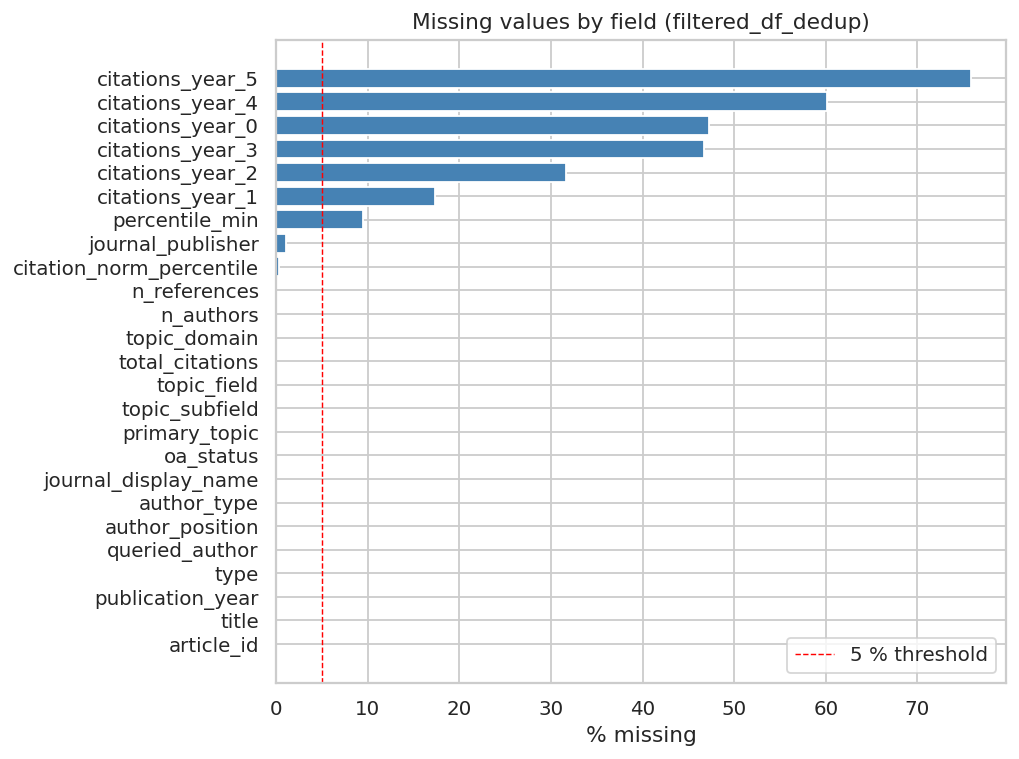

,field,% missing
0,article_id,0.0
1,title,0.0
2,publication_year,0.0
3,type,0.0
4,queried_author,0.0
5,author_position,0.0
6,author_type,0.0
7,journal_display_name,0.0
8,oa_status,0.0
9,primary_topic,0.0


In [448]:
# ── Missing value audit ────────────────────────────────────────────────────────
missing = (
    filtered_df_dedup[base_cols]
    .isnull()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=True)
    .rename("% missing")
    .rename_axis("field")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(missing["field"], missing["% missing"], color="steelblue", edgecolor="white")
ax.set_xlabel("% missing")
ax.set_title("Missing values by field (filtered_df_dedup)")
ax.axvline(5, color="red", linestyle="--", linewidth=0.8, label="5 % threshold")
ax.legend()
plt.tight_layout()
plt.show()

missing


---
##  Citation Analysis
How are citations distributed? Which papers stand out? Do the most-cited papers share common topics? How do citations develop across fields and years?


In [449]:
# ── Descriptive statistics on citations (deduped set) ─────────────────────────
cit = filtered_df_dedup["total_citations"]
stats = cit.describe(percentiles=[0.25, 0.5, 0.75, 0.90])
print(stats.round(1).to_string())
print(f"\n% papers with 0 citations : {(cit == 0).mean() * 100:.1f}%")
print(f"% papers with ≥ 50        : {(cit >= 50).mean() * 100:.1f}%")
print(f"% papers with ≥ 100       : {(cit >= 100).mean() * 100:.1f}%")

count    1382.0
mean       31.7
std        69.3
min         0.0
25%         3.0
50%        11.0
75%        31.0
90%        74.9
max       981.0

% papers with 0 citations : 9.3%
% papers with ≥ 50        : 15.8%
% papers with ≥ 100       : 7.0%


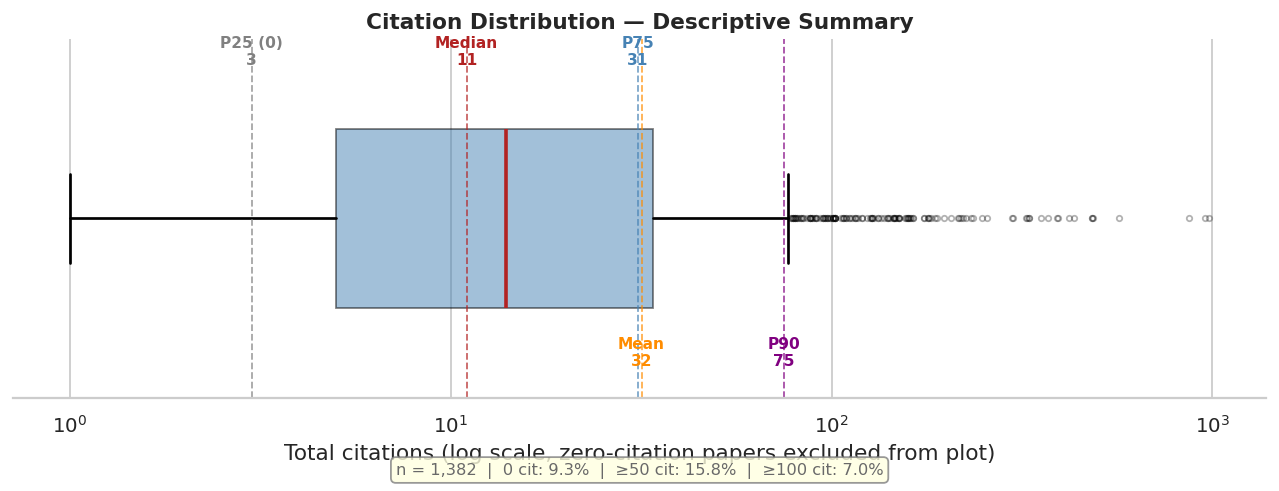

(Note: 129 papers with 0 citations excluded from log-scale plot)


In [450]:

# ── Citation stats summary: boxplot with percentile annotations ───────────────
cit_nonzero = cit[cit > 0]  # log scale requires >0 values

fig, ax = plt.subplots(figsize=(10, 4))

bp = ax.boxplot(
    cit_nonzero, vert=False, patch_artist=True,
    widths=0.5, showfliers=True,
    flierprops=dict(marker="o", markersize=3, alpha=0.3, color="steelblue"),
    medianprops=dict(color="firebrick", linewidth=2),
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

ax.set_xscale("log")

# Annotate key percentiles
percentiles = {
    "P25 (0)": stats["25%"],
    "Median": stats["50%"],
    "Mean": stats["mean"],
    "P75": stats["75%"],
    "P90": stats["90%"],
}
colors_ann = {"P25 (0)": "gray", "Median": "firebrick", "Mean": "darkorange", "P75": "steelblue", "P90": "purple"}
y_offsets = [1.42, 1.42, 0.58, 1.42, 0.58]

for (label, val), y_off in zip(percentiles.items(), y_offsets):
    if val > 0:
        ax.axvline(val, color=colors_ann[label], linestyle="--", linewidth=1, alpha=0.7)
        ax.text(val, y_off, f"{label}\n{val:.0f}", ha="center", va="bottom",
                fontsize=8.5, color=colors_ann[label], fontweight="bold")

# Annotation box with % thresholds
textstr = (
    f"n = {int(stats['count']):,}  |  "
    f"0 cit: {(cit == 0).mean()*100:.1f}%  |  "
    f"≥50 cit: {(cit >= 50).mean()*100:.1f}%  |  "
    f"≥100 cit: {(cit >= 100).mean()*100:.1f}%"
)
ax.text(0.5, -0.18, textstr, transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="dimgray",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray", alpha=0.8))

ax.set_xlabel("Total citations (log scale, zero-citation papers excluded from plot)")
ax.set_yticks([])
ax.set_title("Citation Distribution — Descriptive Summary", fontsize=12, fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()
print(f"(Note: {(cit == 0).sum()} papers with 0 citations excluded from log-scale plot)")


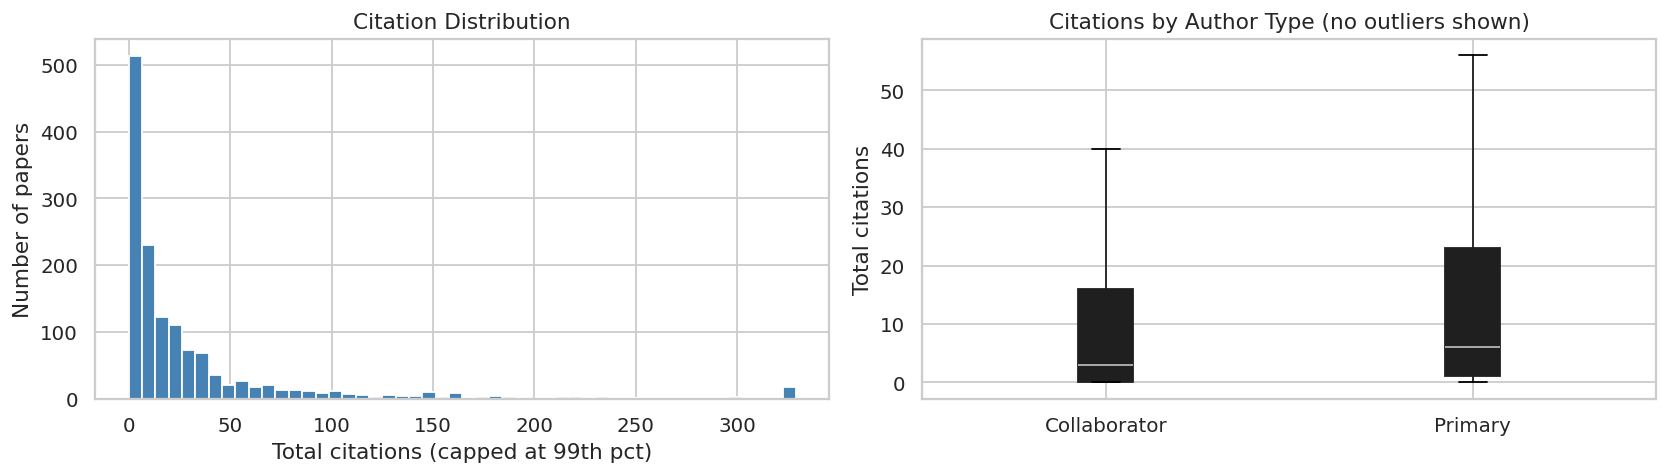

In [451]:
# ── Citation distribution: histogram + boxplot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (log-scale x-axis for heavy tail)
axes[0].hist(cit.clip(upper=cit.quantile(0.99)), bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Total citations (capped at 99th pct)")
axes[0].set_ylabel("Number of papers")
axes[0].set_title("Citation Distribution")

# Boxplot split by author_type
all_df_dedup.boxplot(column="total_citations", by="author_type",
                     ax=axes[1], showfliers=False, patch_artist=True)
axes[1].set_title("Citations by Author Type (no outliers shown)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total citations")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [452]:
# ── Top 25 most-cited papers with topic information ───────────────────────────
top25 = (
    filtered_df_dedup[["title", "queried_author", "publication_year",
                  "journal_display_name", "primary_topic", "topic_field",
                  "total_citations"]]
    .nlargest(25, "total_citations")
    .reset_index(drop=True)
)
top25.index += 1
top25["title"] = top25["title"].str[:65]
print(top25.title.head(10))
print(top25.queried_author.head(10))

1     Life and death in the soil microbiome: how eco...
2     Impacts of Plastic Pollution on Ecosystem Serv...
3     Climate impacts on global agriculture emerge e...
4                 Climate change impacts on crop yields
5     Digital agriculture to design sustainable agri...
6     A global perspective on sustainable intensific...
7     Biochar applications influence soil physical a...
8     Do cover crops benefit soil microbiome? A meta...
9     Role of Cytochrome P450 Enzymes in Plant Stres...
10    Using publicly available satellite imagery and...
Name: title, dtype: str
1      Jinyun Tang
2      Vara Prasad
3     Heidi Webber
4     Heidi Webber
5            Basso
6         Grassini
7      Vara Prasad
8            Kaiyu
9      Vara Prasad
10          Lobell
Name: queried_author, dtype: str


topic_field
Agricultural and Biological Sciences            55.0
Environmental Science                           40.0
Earth and Planetary Sciences                     5.0
Engineering                                      0.0
Biochemistry, Genetics and Molecular Biology     0.0
Medicine                                         0.0
Chemistry                                        0.0
Nursing                                          0.0
Computer Science                                 0.0
Economics, Econometrics and Finance              0.0
Name: count, dtype: float64
topic_field
Agricultural and Biological Sciences            60.3
Environmental Science                           25.0
Earth and Planetary Sciences                     2.1
Engineering                                      3.3
Biochemistry, Genetics and Molecular Biology     2.8
Medicine                                         1.6
Chemistry                                        1.1
Nursing                                        

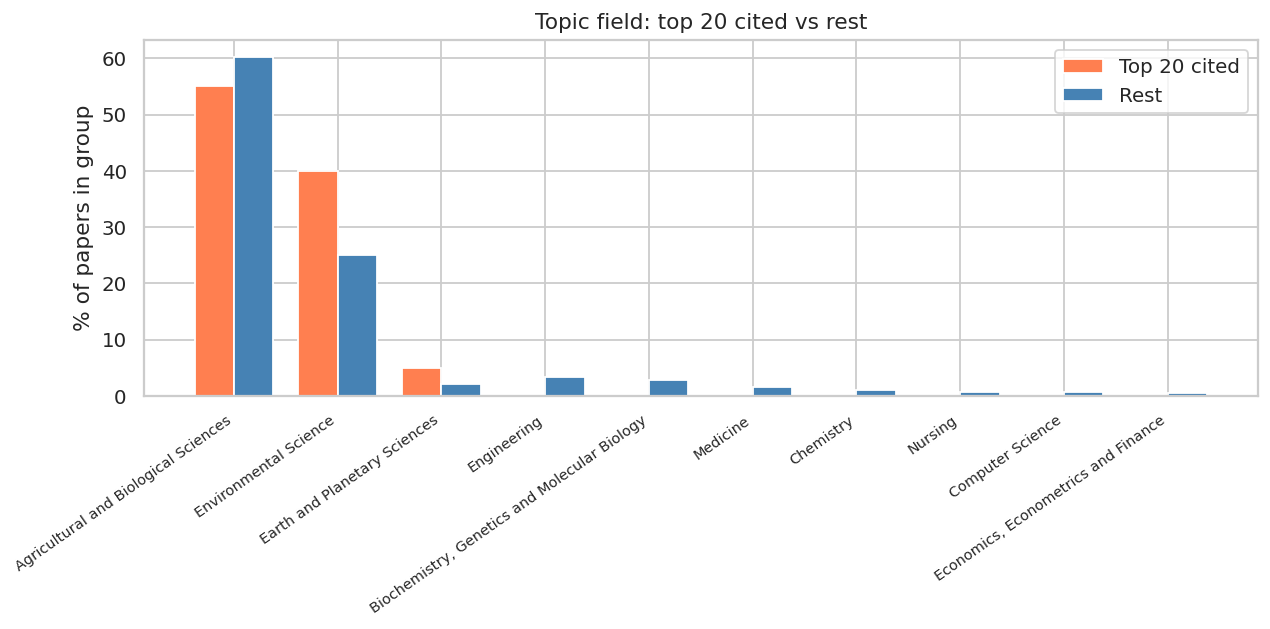

In [453]:
# ── What topics do the top-cited papers share? ───────────────────────────────
TOP_CITE_N = 20   # look at the top-20 most-cited papers

top_cited = filtered_df_dedup.nlargest(TOP_CITE_N, "total_citations")

field_top   = top_cited["topic_field"].value_counts().head(10)
field_rest  = filtered_df_dedup[~filtered_df_dedup["article_id"].isin(top_cited["article_id"])]["topic_field"].value_counts().head(10)

all_fields = list(dict.fromkeys(list(field_top.index) + list(field_rest.index)))
top_pct  = (field_top.reindex(all_fields, fill_value=0) / len(top_cited)  * 100).round(1)
print(top_pct)
rest_pct = (field_rest.reindex(all_fields, fill_value=0) / (len(filtered_df_dedup) - len(top_cited)) * 100).round(1)
print(rest_pct)
x = np.arange(len(all_fields))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, top_pct.values,  w, label=f"Top {TOP_CITE_N} cited", color="coral",     edgecolor="white")
ax.bar(x + w/2, rest_pct.values, w, label="Rest",                    color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(all_fields, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("% of papers in group")
ax.set_title(f"Topic field: top {TOP_CITE_N} cited vs rest")
ax.legend()
plt.tight_layout()
plt.show()


Year 1 (citations_year_0): 1382 papers eligible  →  avg 2.22 citations
Year 2 (citations_year_1): 1119 papers eligible  →  avg 8.97 citations
Year 3 (citations_year_2):  878 papers eligible  →  avg 12.09 citations
Year 4 (citations_year_3):  667 papers eligible  →  avg 13.11 citations


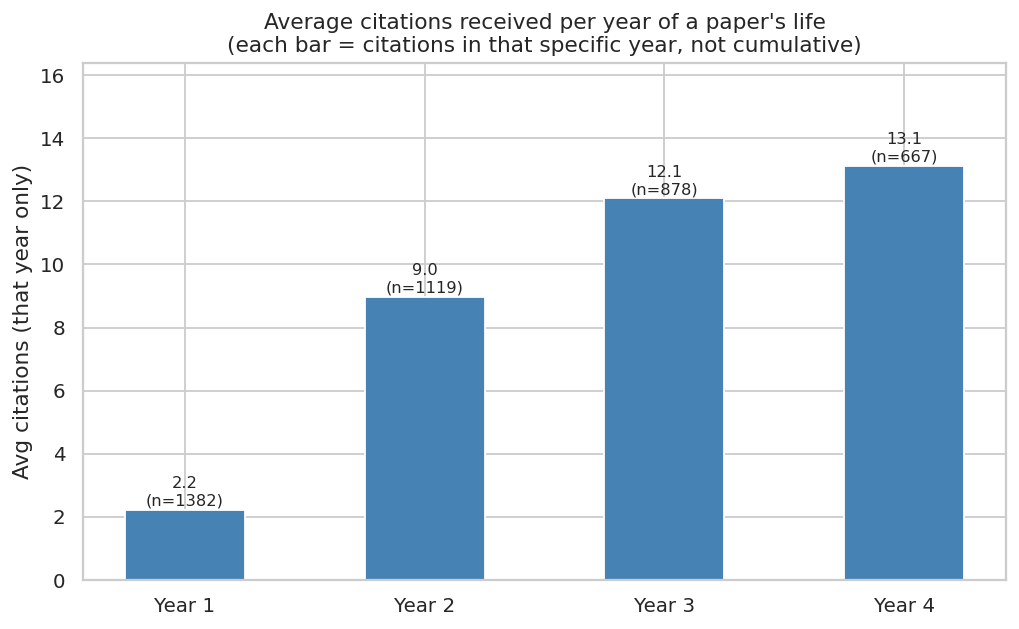

In [454]:
# ── Average citations received per year of a paper's life ─────────────────────
# citations_year_0 = citations received in the publication year (Year 1)
# citations_year_1 = citations received in the 2nd year only   (Year 2)
# ... each column is that single year, NOT cumulative
#
# Eligibility: only papers old enough to have completed that year are included.
# e.g. Year 2 requires publication_year <= 2024 (paper is at least 2 years old)

CURRENT_YEAR = 2026

year_labels  = ["Year 1", "Year 2", "Year 3", "Year 4"]
year_columns = ["citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3"]

avg_per_year = []
n_papers     = []

for label, col, offset in zip(year_labels, year_columns, [1, 2, 3, 4]):
    # Keep only papers old enough to have completed that year
    eligible = filtered_df_dedup[filtered_df_dedup["publication_year"] <= CURRENT_YEAR - offset]
    avg = eligible[col].fillna(0).mean()
    avg_per_year.append(avg)
    n_papers.append(len(eligible))
    print(f"{label} ({col}): {len(eligible):>4} papers eligible  →  avg {avg:.2f} citations")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(year_labels, avg_per_year, color="steelblue", edgecolor="white", width=0.5)

# Annotate each bar with the avg value and paper count
for bar, avg, n in zip(bars, avg_per_year, n_papers):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{avg:.1f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Avg citations (that year only)")
ax.set_title("Average citations received per year of a paper's life\n(each bar = citations in that specific year, not cumulative)")
ax.set_ylim(0, max(avg_per_year) * 1.25)
plt.tight_layout()
plt.show()


Year 1 (cumulative, up to citations_year_0): 1382 papers eligible  →  avg 2.22 citations
Year 2 (cumulative, up to citations_year_1): 1119 papers eligible  →  avg 11.21 citations
Year 3 (cumulative, up to citations_year_2):  878 papers eligible  →  avg 23.43 citations
Year 4 (cumulative, up to citations_year_3):  667 papers eligible  →  avg 36.27 citations


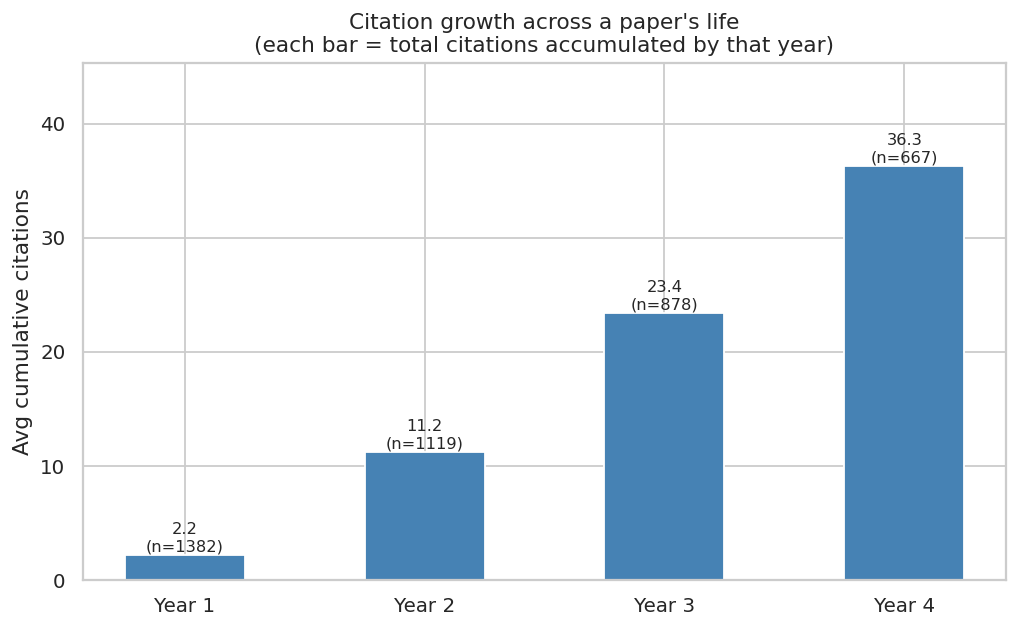

In [455]:

# ── Cumulative citations by year of a paper's life ─────────────────────────────
# Each bar shows the TOTAL citations accumulated from publication up to that year.
# e.g. Year 3 bar = avg(citations_year_0 + citations_year_1 + citations_year_2)
# Eligibility: only papers old enough to have completed that year are included.

avg_cum_per_year = []
n_papers_cum     = []

for i, (label, col, offset) in enumerate(zip(year_labels, year_columns, [1, 2, 3, 4])):
    eligible = filtered_df_dedup[filtered_df_dedup["publication_year"] <= CURRENT_YEAR - offset]
    cum_cols = year_columns[:i + 1]
    avg = eligible[cum_cols].fillna(0).sum(axis=1).mean()
    avg_cum_per_year.append(avg)
    n_papers_cum.append(len(eligible))
    print(f"{label} (cumulative, up to {col}): {len(eligible):>4} papers eligible  →  avg {avg:.2f} citations")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars2 = ax.bar(year_labels, avg_cum_per_year, color="steelblue", edgecolor="white", width=0.5)

for bar, avg, n in zip(bars2, avg_cum_per_year, n_papers_cum):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{avg:.1f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Avg cumulative citations")
ax.set_title("Citation growth across a paper's life\n(each bar = total citations accumulated by that year)")
ax.set_ylim(0, max(avg_cum_per_year) * 1.25)
plt.tight_layout()
plt.show()


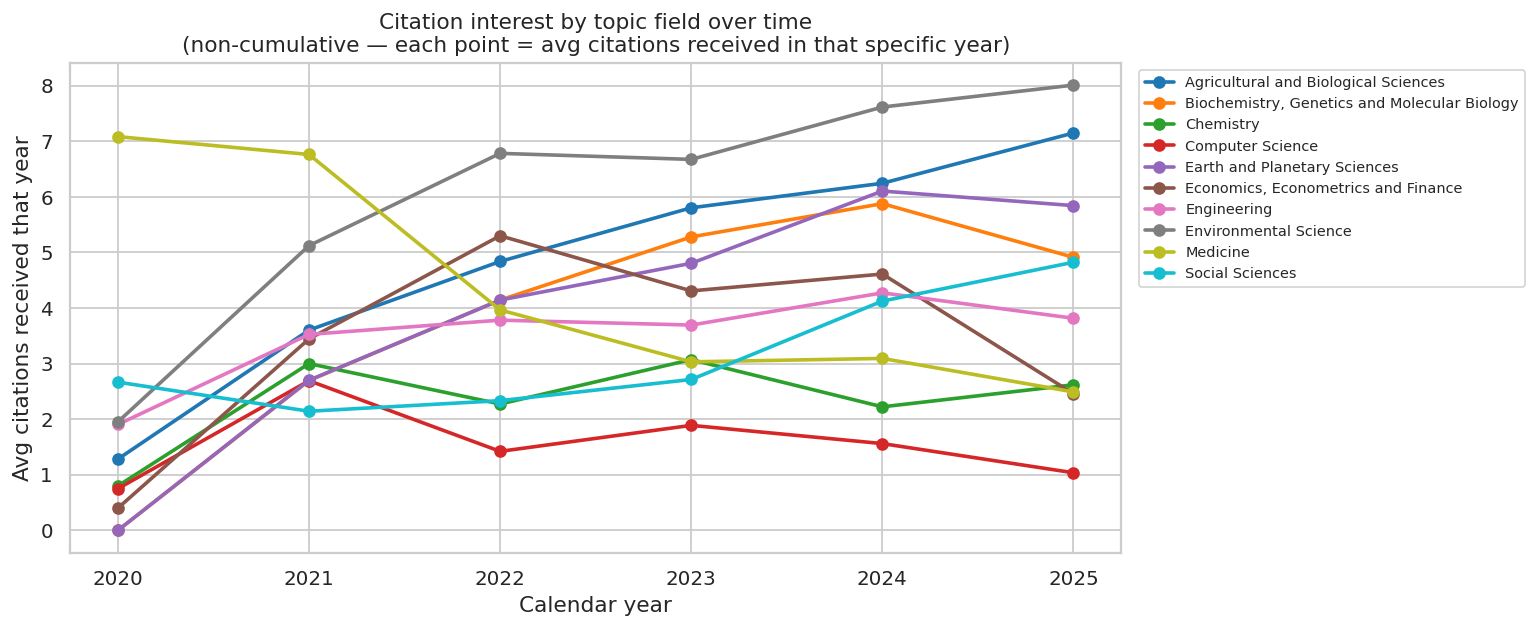

In [456]:
# ── Citation interest trend by topic field ────────────────────────────────────
# For each paper, citations_year_k = citations received in (publication_year + k).
# We convert offsets to actual calendar years, so every paper contributes its
# citations to the year they were received — not cumulative, purely that year.
# This lets us see whether a field's interest is rising or declining over time.

CURRENT_YEAR = 2026
cit_year_cols = [c for c in all_df_dedup.columns if c.startswith("citations_year_")]

top_fields = (
    all_df_dedup.dropna(subset=["topic_field"])
    .groupby("topic_field")["article_id"].count()
    .nlargest(10).index.tolist()
)

df_top = (
    all_df_dedup
    .dropna(subset=["topic_field", "publication_year"])
    .query("topic_field in @top_fields")
)

# Melt citation-year columns into long form, then map offset → calendar year
melted = (
    df_top[["article_id", "topic_field", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "topic_field", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted["offset"]        = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"]     = melted["citations"].fillna(0)

# Keep only complete past calendar years (2020–2025)
melted = melted[(melted["calendar_year"] >= 2020) & (melted["calendar_year"] <= CURRENT_YEAR - 1)]

# Average citations received that calendar year, per field
field_year_avg = (
    melted.groupby(["topic_field", "calendar_year"])["citations"]
    .mean()
    .reset_index()
)

# ── Line chart: one line per field, X = calendar year ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for field, grp in field_year_avg.groupby("topic_field"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["citations"], marker="o", linewidth=2, label=field)

ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations received that year")
ax.set_title("Citation interest by topic field over time\n(non-cumulative — each point = avg citations received in that specific year)")
ax.set_xticks(range(2020, CURRENT_YEAR))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


---
## Author & Authorship Analysis
How productive is each author? What roles do they take (first, middle, last)? Does being corresponding author correlate with more citations?

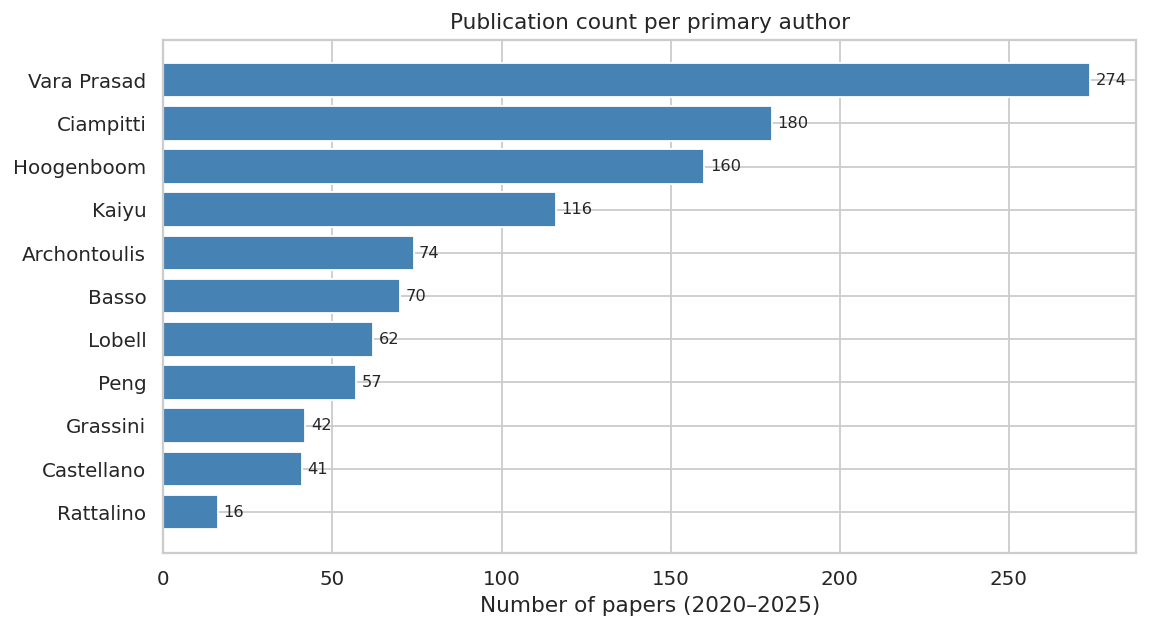

,queried_author,total_papers,avg_citations,corresponding
0,Rattalino,16,37.187500,1
1,Castellano,41,41.414634,4
2,Grassini,42,52.714286,19
3,Peng,57,43.298246,10
4,Lobell,62,64.967742,17
5,Basso,70,35.842857,15
6,Archontoulis,74,32.500000,18
7,Kaiyu,116,46.336207,55
8,Hoogenboom,160,23.006250,10
9,Ciampitti,180,22.344444,87


In [457]:
# ── Papers per primary author — total & yearly breakdown ─────────────────────
author_counts = (
    primary_filtered_dedup
    .groupby("queried_author")
    .agg(
        total_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
        corresponding=("is_corresponding_author", "sum"),
    )
    .sort_values("total_papers", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(author_counts["queried_author"], author_counts["total_papers"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of papers (2020–2025)")
ax.set_title("Publication count per primary author")
plt.tight_layout()
plt.show()
author_counts


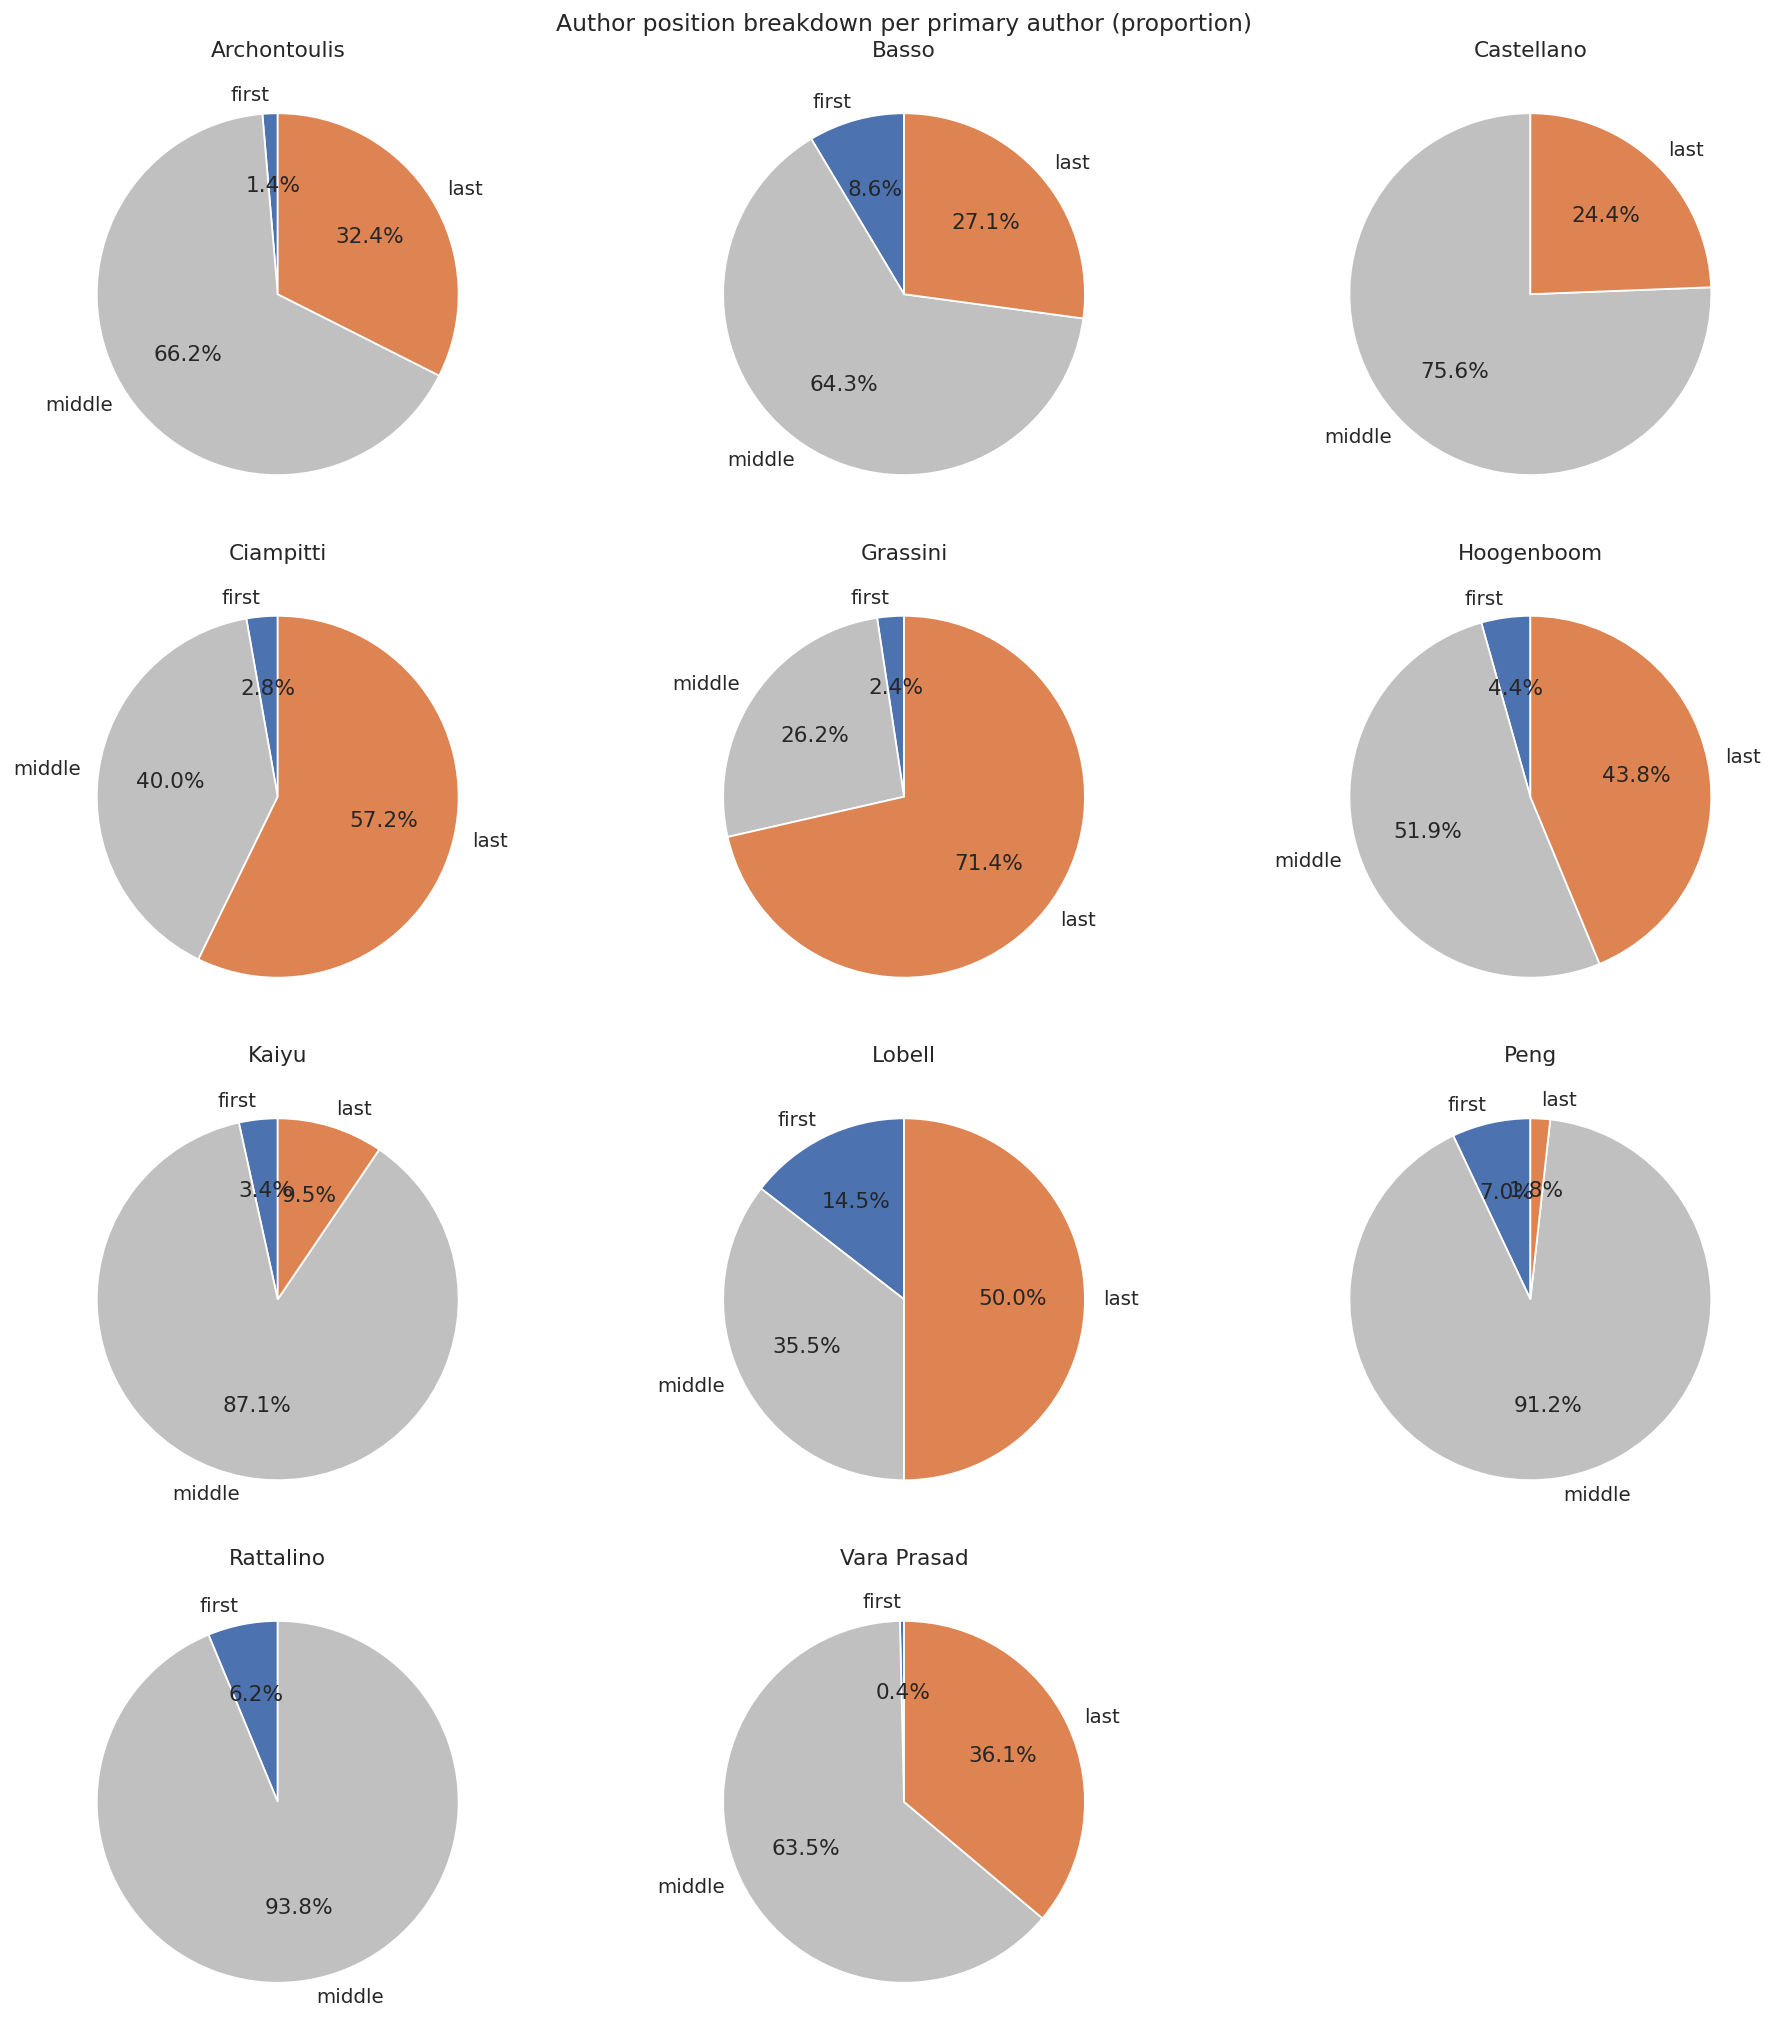

In [458]:
# ── Author position breakdown (pie – proportions) ─────────────────────────────
pos_counts = (
    primary_filtered_dedup
    .groupby(["queried_author", "author_position"])
    .size()
    .unstack(fill_value=0)
)
pos_order = ["first", "middle", "last"]
pos_counts = pos_counts.reindex(columns=[c for c in pos_order if c in pos_counts.columns])

colors = {"first": "#4C72B0", "middle": "#C0C0C0", "last": "#DD8452"}

n_authors = len(pos_counts)
ncols = min(3, n_authors)
nrows = int(np.ceil(n_authors / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, (author_name, row) in enumerate(pos_counts.iterrows()):
    row = row[row > 0]
    col_colors = [colors.get(c, "gray") for c in row.index]
    axes_flat[i].pie(
        row.values,
        labels=row.index,
        colors=col_colors,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"},
    )
    axes_flat[i].set_title(author_name)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Author position breakdown per primary author (proportion)", fontsize=13)
plt.tight_layout()
plt.show()

Average citations — corresponding vs non-corresponding:

                         mean  median  count
is_corresponding_author                     
Non-corresponding        34.2    12.0    826
Corresponding            32.7    14.0    266


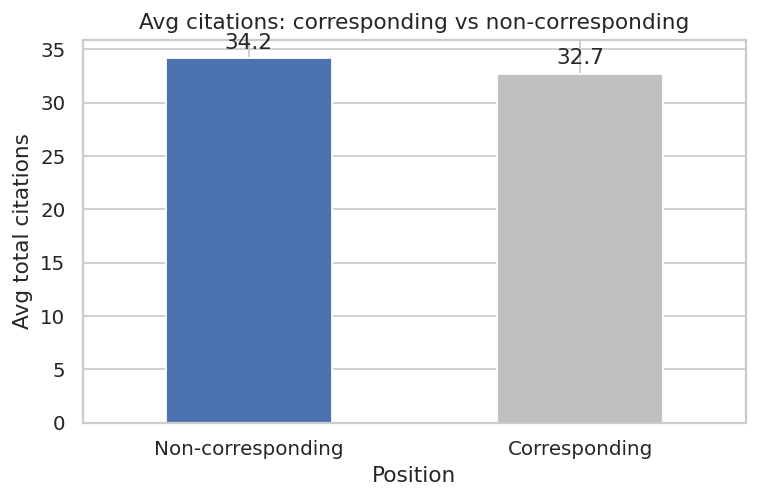

In [459]:
# ── Corresponding author: citation impact ─────────────────────────────────────
corr_cit = (
    primary_filtered_dedup
    .groupby("is_corresponding_author")["total_citations"]
    .agg(["mean", "median", "count"])
    .rename(index={True: "Corresponding", False: "Non-corresponding"})
)
print("Average citations — corresponding vs non-corresponding:\n")
print(corr_cit.round(1).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
corr_cit["mean"].plot.bar(ax=ax, color=["#4C72B0", "#C0C0C0"], edgecolor="white", rot=0)
ax.set_ylabel("Avg total citations")
ax.set_title("Avg citations: corresponding vs non-corresponding")
ax.set_xlabel("Position")
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()

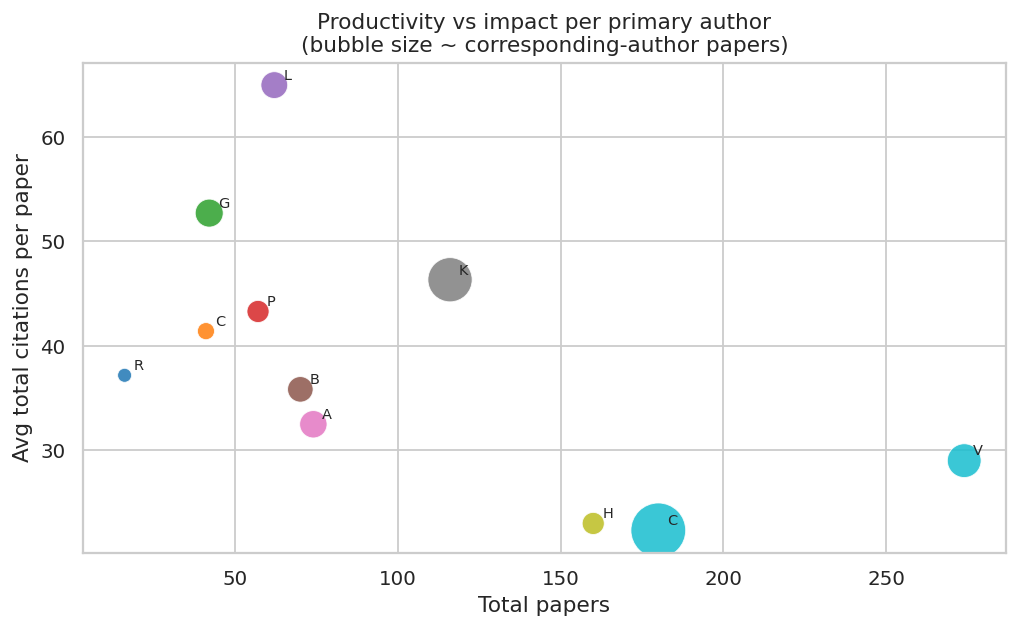

In [460]:
# ── Ranked dot plot: papers count vs avg citations per primary author ─────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    author_counts["total_papers"],
    author_counts["avg_citations"],
    s=author_counts["corresponding"] * 10 + 50,
    c=range(len(author_counts)),
    cmap="tab10",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
)
for _, row in author_counts.iterrows():
    ax.annotate(row["queried_author"][0], 
                xy=(row["total_papers"], row["avg_citations"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("Total papers")
ax.set_ylabel("Avg total citations per paper")
ax.set_title("Productivity vs impact per primary author\n(bubble size ~ corresponding-author papers)")
plt.tight_layout()
plt.show()

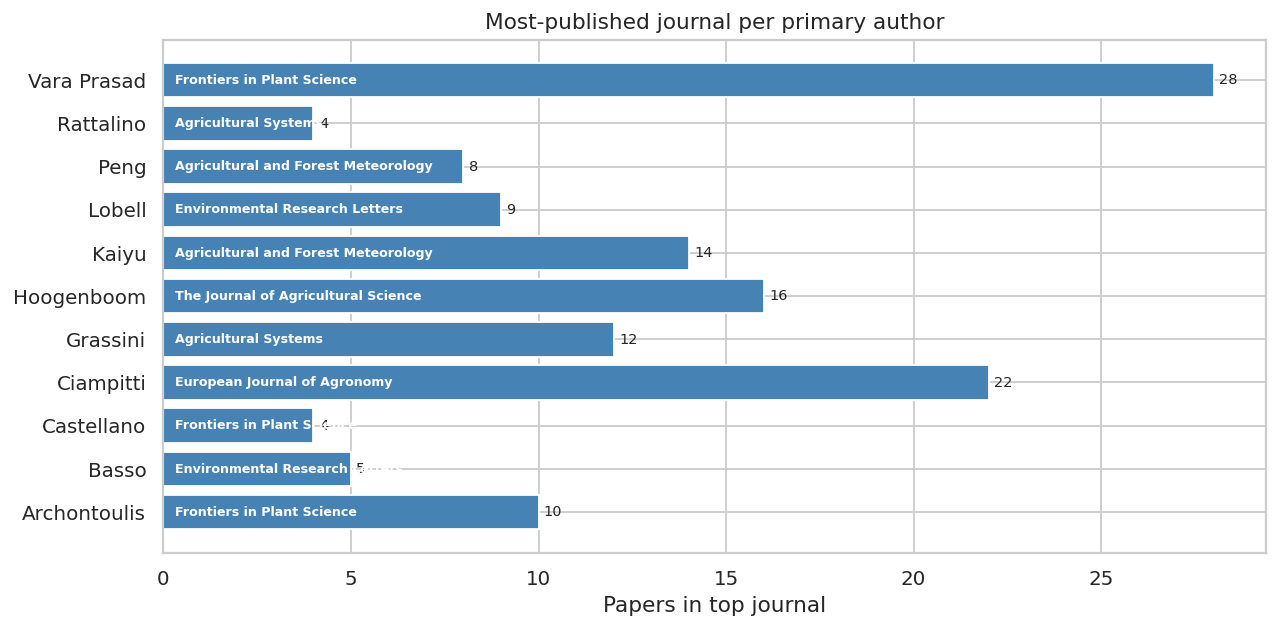


Top journal per primary author:
queried_author                         top_journal  n_papers
  Archontoulis          Frontiers in Plant Science        10
         Basso      Environmental Research Letters         5
    Castellano          Frontiers in Plant Science         4
     Ciampitti        European Journal of Agronomy        22
      Grassini                Agricultural Systems        12
    Hoogenboom The Journal of Agricultural Science        16
         Kaiyu Agricultural and Forest Meteorology        14
        Lobell      Environmental Research Letters         9
          Peng Agricultural and Forest Meteorology         8
     Rattalino                Agricultural Systems         4
   Vara Prasad          Frontiers in Plant Science        28


In [461]:
# ── Most-published journal per primary author ─────────────────────────────────
top_journal_per_author = (
    primary_filtered_dedup.dropna(subset=["journal_display_name"])
    .groupby(["queried_author", "journal_display_name"])
    .size()
    .reset_index(name="n_papers")
    .sort_values("n_papers", ascending=False)
    .groupby("queried_author")
    .first()
    .reset_index()
    .rename(columns={"journal_display_name": "top_journal"})
    [["queried_author", "top_journal", "n_papers"]]
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_journal_per_author["queried_author"],
    top_journal_per_author["n_papers"],
    color="steelblue", edgecolor="white"
)
ax.bar_label(bars, padding=3, fontsize=8)
for i, (_, row) in enumerate(top_journal_per_author.iterrows()):
    ax.text(
        0.3, i, row["top_journal"][:40],
        va="center", fontsize=7, color="white", fontweight="bold"
    )
ax.set_xlabel("Papers in top journal")
ax.set_title("Most-published journal per primary author")
plt.tight_layout()
plt.show()

print("\nTop journal per primary author:")
print(top_journal_per_author.to_string(index=False))


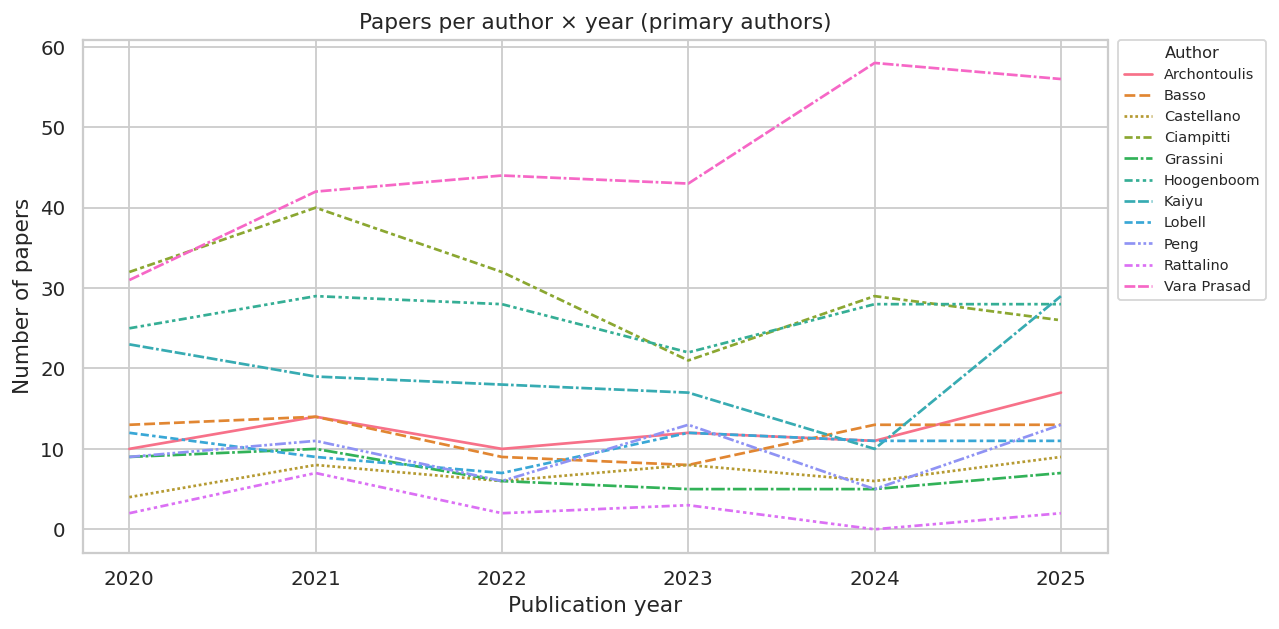

In [462]:
# ── Author activity: papers per author × year ─────────────────────────────────
act_pivot = (
    primary_filtered_dedup
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=act_pivot.T, ax=ax)
ax.set_title("Papers per author × year (primary authors)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Author", fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


---
##  Journal & Publisher Analysis
Where are these agronomists publishing? Which journals have the highest citation impact for this community?

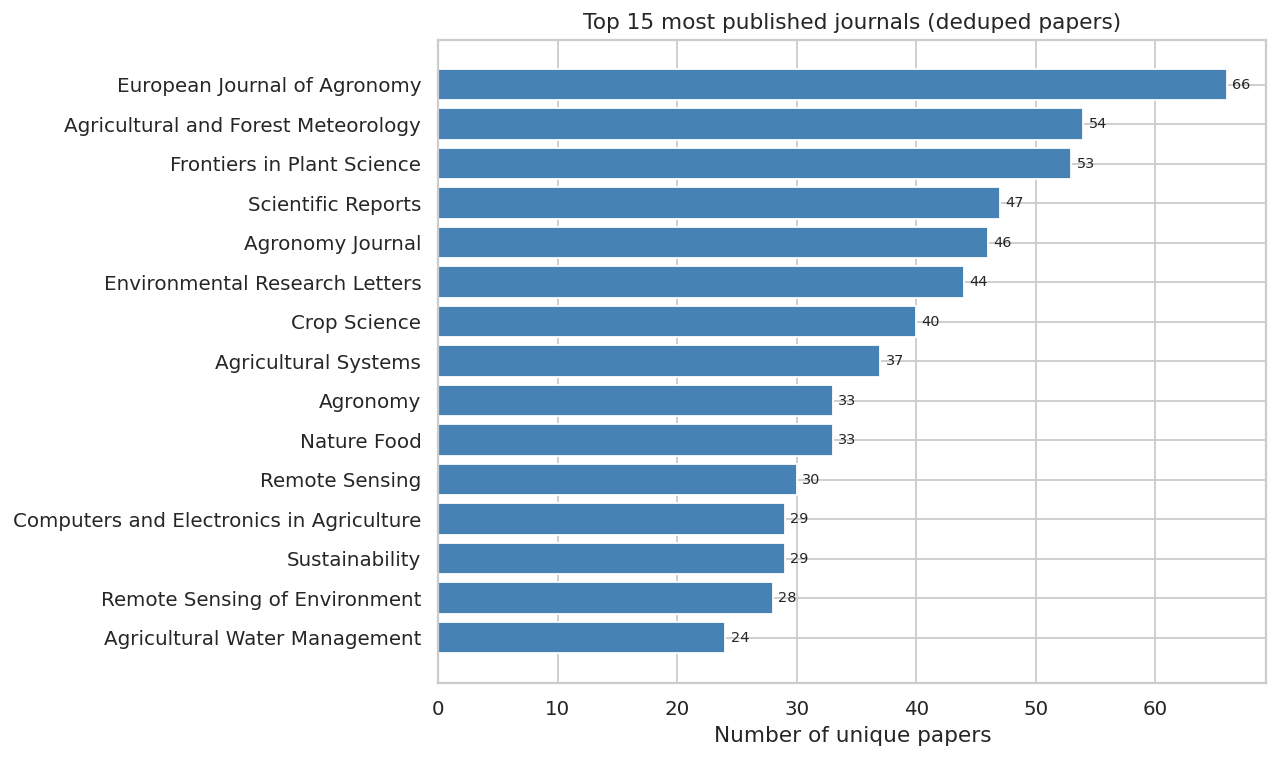

                    journal_display_name  total_publications  avg_citations
            European Journal of Agronomy                  66      25.787879
     Agricultural and Forest Meteorology                  54      34.166667
              Frontiers in Plant Science                  53      32.981132
                      Scientific Reports                  47      21.361702
                        Agronomy Journal                  46      12.130435
          Environmental Research Letters                  44      39.659091
                            Crop Science                  40      17.050000
                    Agricultural Systems                  37      22.972973
                                Agronomy                  33      14.242424
                             Nature Food                  33      72.939394
                          Remote Sensing                  30      31.500000
Computers and Electronics in Agriculture                  29      17.137931
            

In [463]:
# ── Top 15 journals by publication count (deduped) ────────────────────────────
journal_counts = (
    filtered_df_dedup
    .dropna(subset=["journal_display_name"])
    .groupby("journal_display_name")
    .agg(
        total_publications=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
    )
    .sort_values("total_publications", ascending=False)
    .head(15)
    .sort_values("total_publications", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(journal_counts["journal_display_name"],
               journal_counts["total_publications"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Number of unique papers")
ax.set_title("Top 15 most published journals (deduped papers)")
plt.tight_layout()
plt.show()
print(journal_counts.sort_values("total_publications", ascending=False).to_string(index=False))

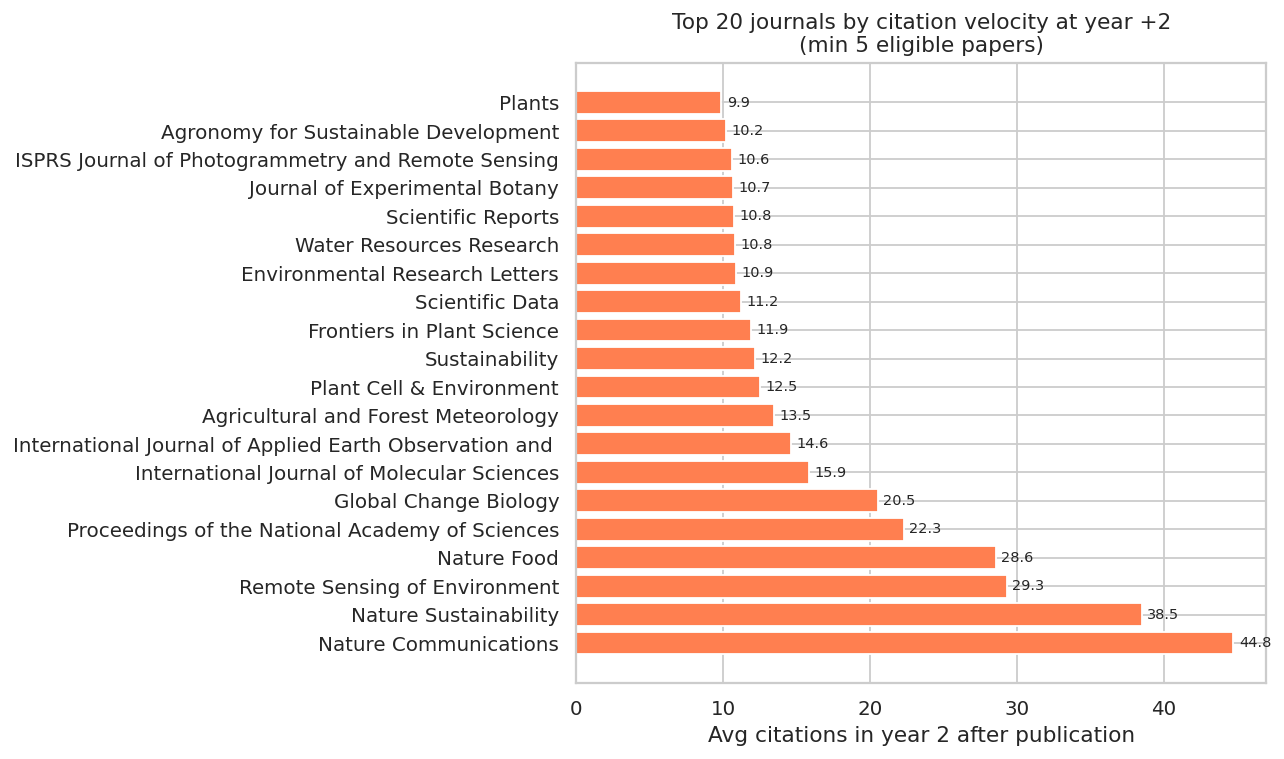

In [464]:
# ── Journal avg citations at y=2 (papers old enough) ─────────────────────────
CURRENT_YEAR = 2026
df_jnl = filtered_df_dedup.copy()
df_jnl["age"] = CURRENT_YEAR - df_jnl["publication_year"].fillna(CURRENT_YEAR)
df_jnl["citations_year_2"] = df_jnl.get("citations_year_2", pd.Series(dtype=float))

eligible = df_jnl[df_jnl["age"] >= 2].dropna(subset=["journal_display_name", "citations_year_2"])
jnl_avg = (
    eligible.groupby("journal_display_name")
    .agg(
        n=("article_id", "count"),
        avg_cit_yr2=("citations_year_2", "mean"),
        total_pubs_in_dataset=("article_id", "count"),
    )
    .query("n >= 5")
    .sort_values("avg_cit_yr2", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    jnl_avg["journal_display_name"].str[:55],
    jnl_avg["avg_cit_yr2"],
    color="coral", edgecolor="white",
)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("Avg citations in year 2 after publication")
ax.set_title("Top 20 journals by citation velocity at year +2\n(min 5 eligible papers)")
plt.tight_layout()
plt.show()

In [465]:
# # ── Volume vs impact scatter (min 5 papers per journal) ─────────────────────────
# jnl_scatter = (
#     all_df_dedup
#     .dropna(subset=["journal_display_name"])
#     .groupby("journal_display_name")
#     .agg(n_pubs=("article_id", "count"), avg_cit=("total_citations", "mean"))
#     .query("n_pubs >= 5")
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(9, 6))
# ax.scatter(jnl_scatter["n_pubs"], jnl_scatter["avg_cit"],
#            alpha=0.7, s=50, color="steelblue", edgecolors="white")

# # Label top 10 by avg citations
# top_label = jnl_scatter.nlargest(10, "avg_cit")
# for _, row in top_label.iterrows():
#     ax.annotate(row["journal_display_name"][:30],
#                 xy=(row["n_pubs"], row["avg_cit"]),
#                 xytext=(5, 3), textcoords="offset points", fontsize=7)

# ax.set_xlabel("Number of papers published")
# ax.set_ylabel("Avg total citations per paper")
# ax.set_title("Journal volume vs citation impact\n(journals with ≥5 papers)")
# plt.tight_layout()
# plt.show()

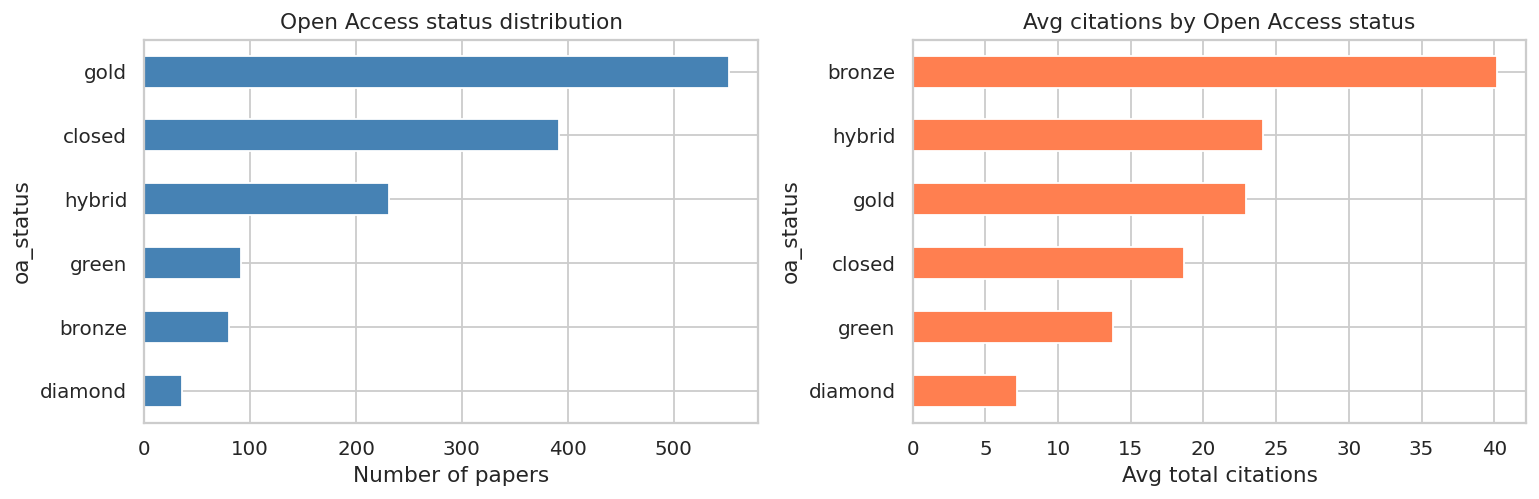

In [466]:
# ── Open Access status breakdown ──────────────────────────────────────────────
oa_counts = (
    filtered_df_dedup["oa_status"]
    .fillna("unknown")
    .value_counts()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OA status distribution
oa_counts.plot.barh(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Open Access status distribution")
axes[0].set_xlabel("Number of papers")

# OA status vs avg citations
oa_cit = (
    all_df_dedup
    .assign(oa_status=lambda d: d["oa_status"].fillna("unknown"))
    .groupby("oa_status")["total_citations"]
    .mean()
    .sort_values(ascending=True)
)
oa_cit.plot.barh(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Avg citations by Open Access status")
axes[1].set_xlabel("Avg total citations")

plt.tight_layout()
plt.show()

# Labels
### Diamond,
"The ""Gold Standard"": Published in a journal that is free for both authors to publish in and readers to read. No fees involved."
### Gold,
"Published in a fully Open Access journal. Usually, authors (or their institutions) pay an APC (Article Processing Charge) to make it free for everyone."
### Hybrid,
"Published in a ""subscription"" journal (like Nature), but the author paid a specific fee to make their individual article open access."
### Bronze,
"Free to read on the publisher's website, but it has no clear license (like Creative Commons). The publisher could put it back behind a paywall at any time."
### Green,
"The version on the publisher's site is ""Closed,"" but the author has uploaded a free copy (like a preprint or post-print) to a repository (like arXiv or a university library)."

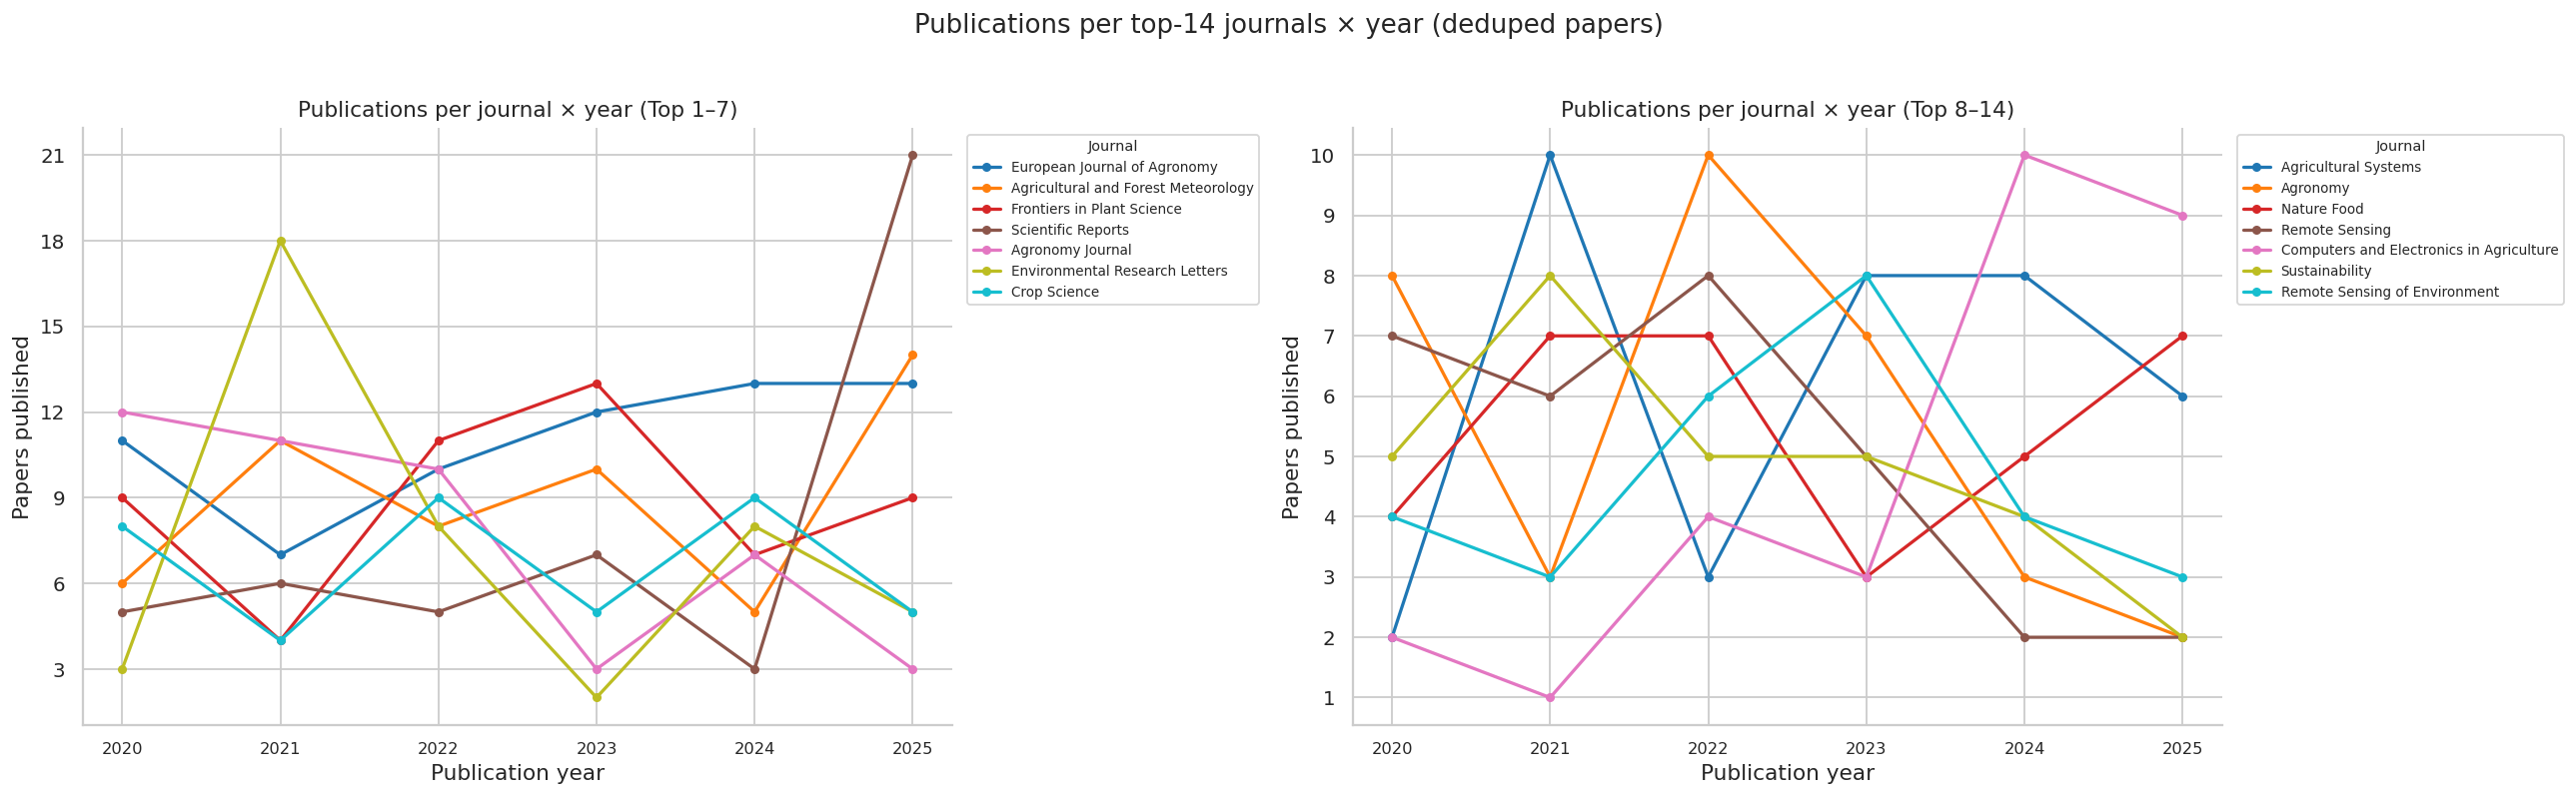

In [467]:

# ── Publications per top journal × year (line charts, split into 2 groups of 7) ──
top15_journals = (
    filtered_df_dedup.dropna(subset=["journal_display_name"])
    .groupby("journal_display_name")["article_id"].count()
    .nlargest(14).index.tolist()
)

jnl_year_pivot = (
    filtered_df_dedup
    .dropna(subset=["journal_display_name", "publication_year"])
    .query("journal_display_name in @top15_journals")
    .groupby(["journal_display_name", "publication_year"])
    .size()
    .unstack(fill_value=0)
    .reindex(top15_journals)
)
# Sort by total publications descending
jnl_year_pivot = jnl_year_pivot.loc[jnl_year_pivot.sum(axis=1).sort_values(ascending=False).index]

groups = [jnl_year_pivot.iloc[:7], jnl_year_pivot.iloc[7:]]
group_labels = ["Top 1–7", "Top 8–14"]

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=False)

for ax, group_df, g_label in zip(axes, groups, group_labels):
    cmap_lines = plt.get_cmap("tab10", len(group_df))
    for i, (journal, row) in enumerate(group_df.iterrows()):
        ax.plot(row.index.astype(int), row.values, marker="o", markersize=4,
                linewidth=1.8, label=journal, color=cmap_lines(i))
    ax.set_title(f"Publications per journal × year ({g_label})")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Papers published")
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7.5,
              frameon=True, title="Journal", title_fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Publications per top-14 journals × year (deduped papers)", y=1.02)
plt.tight_layout()
plt.show()


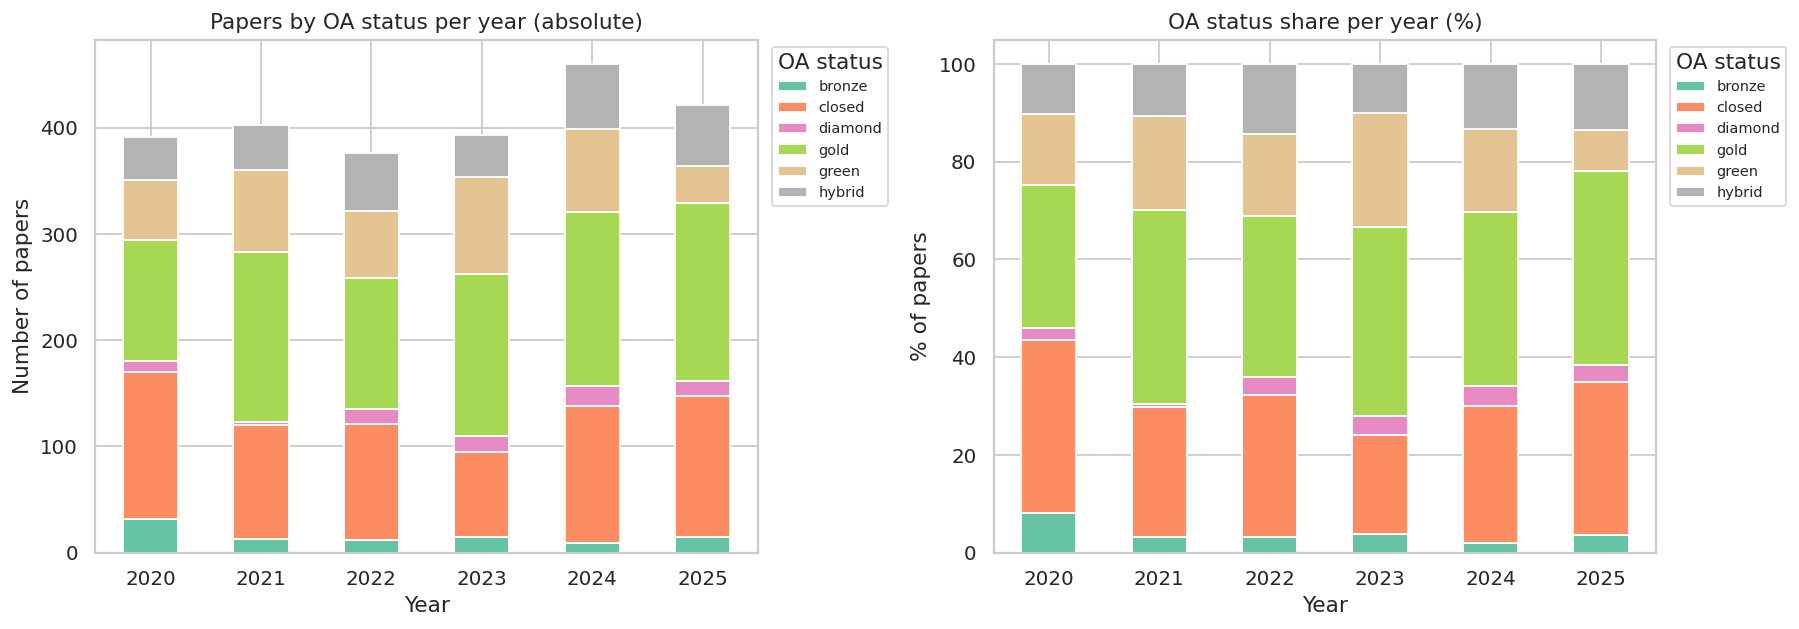

In [468]:
# ── Open Access trends over time ──────────────────────────────────────────────
oa_yearly = (
    all_df_dedup
    .dropna(subset=["publication_year", "oa_status"])
    .groupby(["publication_year", "oa_status"])
    .size()
    .unstack(fill_value=0)
)
# Express as % of papers per year
oa_yearly_pct = oa_yearly.div(oa_yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts stacked
oa_yearly.plot.bar(stacked=True, ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Papers by OA status per year (absolute)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of papers")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="OA status", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# Right: percentage stacked
oa_yearly_pct.plot.bar(stacked=True, ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("OA status share per year (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of papers")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="OA status", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


<!-- ---
## 7. Concept & Topic Tag Analysis
OpenAlex tags every paper with structured **concepts** at multiple specificity levels (0 = broadest, 3+ = most specific).  
This section surfaces dominant research themes without topic modeling. -->

In [469]:
# # ── Extract concept data from primary_works ───────────────────────────────────
# concept_data = defaultdict(lambda: {"name": "", "level": 0, "count": 0, "score_sum": 0.0, "paper_ids": set()})

# for work in all_works:
#     wid = work.get("id")
#     for concept in work.get("concepts", []):
#         cid = concept["id"]
#         concept_data[cid]["name"]       = concept["display_name"]
#         concept_data[cid]["level"]      = concept["level"]
#         concept_data[cid]["count"]     += 1
#         concept_data[cid]["score_sum"] += concept.get("score", 0.0)
#         concept_data[cid]["paper_ids"].add(wid)

# concept_df = pd.DataFrame([
#     {
#         "concept_id":   cid,
#         "concept_name": d["name"],
#         "level":        d["level"],
#         "count":        d["count"],
#         "score_sum":    round(d["score_sum"], 2),
#         "avg_score":    round(d["score_sum"] / d["count"], 3),
#         "n_papers":     len(d["paper_ids"]),
#     }
#     for cid, d in concept_data.items()
# ]).sort_values("count", ascending=False).reset_index(drop=True)

# print(f"Unique concepts extracted: {len(concept_df)}")
# print(f"\nConcepts by level:")
# print(concept_df.groupby("level")["concept_id"].count().rename("count").to_string())
# concept_df.head(10)

In [470]:
# # ── Top 30 concepts at level ≥ 2 by occurrence count ─────────────────────────
# top_concepts = (
#     concept_df[concept_df["level"] >= 2]
#     .nlargest(30, "count")
#     .sort_values("count", ascending=True)
#     .reset_index(drop=True)
# )

# fig, ax = plt.subplots(figsize=(10, 9))
# colors_list = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top_concepts)))
# bars = ax.barh(top_concepts["concept_name"], top_concepts["count"],
#                color=colors_list, edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=8)
# ax.set_xlabel("Number of papers tagged with this concept")
# ax.set_title("Top 30 specific concepts (level ≥ 2) in primary author publications")
# plt.tight_layout()
# plt.show()

In [471]:
# # ── Concept co-occurrence: which concepts share the same papers? ──────────────
# # Build paper → concept list mapping (level ≥ 2, top 25 concepts)
# top_concept_names = set(
#     concept_df[concept_df["level"] >= 2].nlargest(25, "count")["concept_name"]
# )

# paper_concepts = defaultdict(set)
# for work in primary_works:
#     wid = work.get("id")
#     for c in work.get("concepts", []):
#         if c["level"] >= 2 and c["display_name"] in top_concept_names:
#             paper_concepts[wid].add(c["display_name"])

# # Build co-occurrence matrix
# co_occur = defaultdict(Counter)
# for cset in paper_concepts.values():
#     clist = sorted(cset)
#     for i, a in enumerate(clist):
#         for b in clist[i + 1:]:
#             co_occur[a][b] += 1
#             co_occur[b][a] += 1

# all_concepts = sorted(top_concept_names)
# co_matrix = pd.DataFrame(
#     [[co_occur[a][b] for b in all_concepts] for a in all_concepts],
#     index=all_concepts, columns=all_concepts,
# )

# fig, ax = plt.subplots(figsize=(13, 11))
# mask = np.triu(np.ones_like(co_matrix, dtype=bool))  # upper triangle
# sns.heatmap(
#     co_matrix, mask=mask, annot=False, fmt="d", cmap="YlOrRd",
#     linewidths=0.3, ax=ax, cbar_kws={"label": "co-occurrences"},
# )
# ax.set_title("Concept co-occurrence heatmap (top 25 specific concepts, level ≥ 2)")
# ax.tick_params(axis="x", rotation=45, labelsize=8)
# ax.tick_params(axis="y", labelsize=8)
# plt.tight_layout()
# plt.show()

In [472]:
# # ── Top concept pairs ─────────────────────────────────────────────────────────
# pairs = []
# for a in all_concepts:
#     for b in all_concepts:
#         if a < b and co_occur[a][b] > 0:
#             pairs.append({"concept_a": a, "concept_b": b, "co_occurrences": co_occur[a][b]})

# pairs_df = pd.DataFrame(pairs).sort_values("co_occurrences", ascending=False).reset_index(drop=True)
# print("Top 20 concept pairs by co-occurrence:\n")
# print(pairs_df.head(20).to_string(index=False))

### 7c. Structured Topic Hierarchy (OpenAlex Topics)
OpenAlex also assigns each paper a **primary topic** with a 4-level hierarchy: Domain → Field → Subfield → Topic.  
This is cleaner and more structured than the legacy concepts — we use it here for time-based analysis.


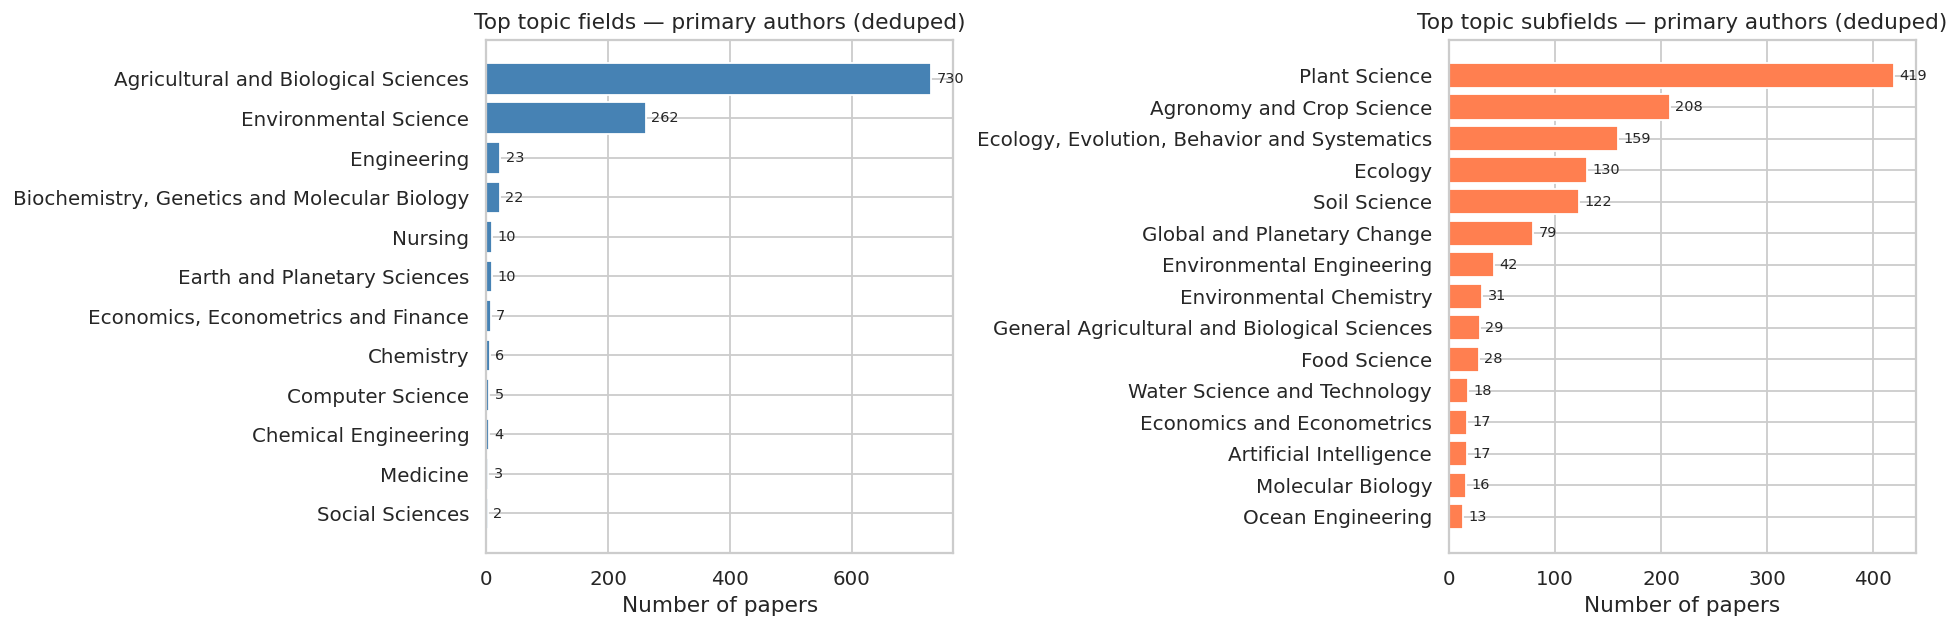

In [473]:
# ── Topic field & subfield distribution (primary deduped papers) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: top topic fields
top_tf = (
    primary_filtered_dedup.dropna(subset=["topic_field"])
    .groupby("topic_field")["article_id"].count()
    .sort_values(ascending=True).tail(12)
)
bars = axes[0].barh(top_tf.index, top_tf.values, color="steelblue", edgecolor="white")
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_title("Top topic fields — primary authors (deduped)")
axes[0].set_xlabel("Number of papers")

# Right: top subfields
top_sf = (
    primary_dedup.dropna(subset=["topic_subfield"])
    .groupby("topic_subfield")["article_id"].count()
    .sort_values(ascending=True).tail(15)
)
bars2 = axes[1].barh(top_sf.index, top_sf.values, color="coral", edgecolor="white")
axes[1].bar_label(bars2, padding=3, fontsize=8)
axes[1].set_title("Top topic subfields — primary authors (deduped)")
axes[1].set_xlabel("Number of papers")

plt.tight_layout()
plt.show()


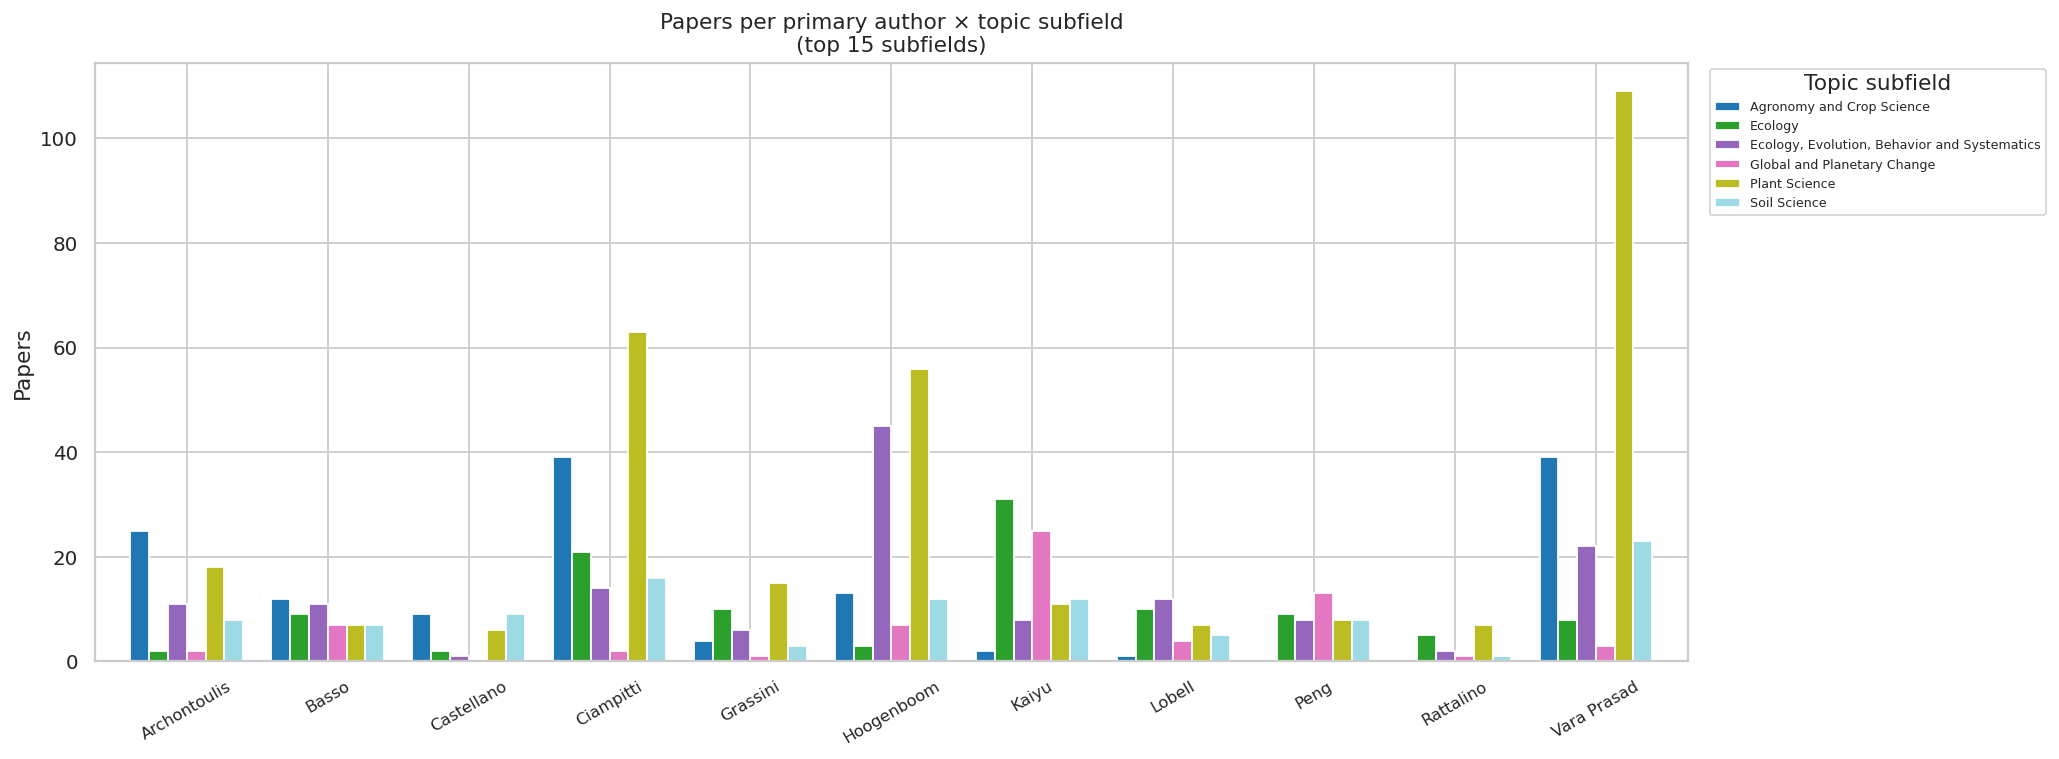


Top 3 topic subfields per primary author:
queried_author                               topic_subfield   n
   Vara Prasad                                Plant Science 109
     Ciampitti                                Plant Science  63
    Hoogenboom                                Plant Science  56
    Hoogenboom Ecology, Evolution, Behavior and Systematics  45
     Ciampitti                    Agronomy and Crop Science  39
   Vara Prasad                    Agronomy and Crop Science  39
         Kaiyu                                      Ecology  31
         Kaiyu                  Global and Planetary Change  25
  Archontoulis                    Agronomy and Crop Science  25
   Vara Prasad                                 Soil Science  23
     Ciampitti                                      Ecology  21
  Archontoulis                                Plant Science  18
      Grassini                                Plant Science  15
          Peng                  Global and Planetary Change  

In [474]:

# ── Dominant topic subfield per primary author ────────────────────────────────
author_topic = (
    primary_filtered_dedup.dropna(subset=["topic_subfield"])
    .groupby(["queried_author", "topic_subfield"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("queried_author")
    .head(3)          # top 3 subfields per author
    .reset_index(drop=True)
)

# Also make a pivot for a bar chart (top 15 subfields)
top_subfields = author_topic.groupby("topic_subfield")["n"].sum().nlargest(15).index
author_subfield_pivot = (
    primary_filtered_dedup.dropna(subset=["topic_subfield"])
    .query("topic_subfield in @top_subfields")
    .groupby(["queried_author", "topic_subfield"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 6))
author_subfield_pivot.plot(
    kind="bar",
    stacked=False,
    colormap="tab20",
    ax=ax,
    width=0.8
)
ax.set_title("Papers per primary author × topic subfield\n(top 15 subfields)")
ax.set_xlabel("")
ax.set_ylabel("Papers")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.legend(title="Topic subfield", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

print("\nTop 3 topic subfields per primary author:")
print(author_topic.to_string(index=False))


### 7b. Concept Trends Over Time
How has the prevalence of each research theme shifted year by year (2020–2025)?

In [475]:
# # ── Build concept × year frequency table ─────────────────────────────────────
# # For every paper in primary_works, record which concepts it has per pub year
# concept_year_rows = []
# for work in primary_works:
#     year = work.get("publication_year")
#     if not year:
#         continue
#     for c in work.get("concepts", []):
#         if c["level"] >= 2:
#             concept_year_rows.append({
#                 "concept_name": c["display_name"],
#                 "year":         year,
#                 "score":        c.get("score", 0.0),
#             })

# concept_year_df = pd.DataFrame(concept_year_rows)

# # Total papers per year (denominator for normalisation)
# papers_per_year = (
#     pd.DataFrame([
#         {"year": w.get("publication_year"), "article_id": w.get("id")}
#         for w in primary_works if w.get("publication_year")
#     ])
#     .drop_duplicates("article_id")
#     .groupby("year").size()
#     .rename("total_papers")
# )

# # Count appearances of each concept per year
# concept_yearly = (
#     concept_year_df
#     .groupby(["concept_name", "year"])
#     .size()
#     .reset_index(name="n_papers")
# )

# # Join with total papers to get % prevalence
# concept_yearly = concept_yearly.merge(
#     papers_per_year.reset_index(), on="year", how="left"
# )
# concept_yearly["pct_papers"] = (concept_yearly["n_papers"] / concept_yearly["total_papers"] * 100).round(2)

# # Pivot: rows = concept, cols = year
# concept_pivot_abs = (
#     concept_yearly.pivot_table(index="concept_name", columns="year",
#                                values="n_papers", aggfunc="sum", fill_value=0)
# )
# concept_pivot_pct = (
#     concept_yearly.pivot_table(index="concept_name", columns="year",
#                                values="pct_papers", aggfunc="mean", fill_value=0)
# )

# print(f"Concepts tracked: {len(concept_pivot_abs)}  |  Years: {list(concept_pivot_abs.columns)}")

In [476]:
# # ── Line chart: top 15 concepts — % of papers per year ───────────────────────
# TOP_N = 15
# # Select top concepts by total count across all years
# top15_names = (
#     concept_pivot_abs.sum(axis=1)
#     .nlargest(TOP_N)
#     .index.tolist()
# )

# top15_pct = concept_pivot_pct.loc[
#     concept_pivot_pct.index.isin(top15_names)
# ].T  # transpose so years are rows

# years_available = sorted(top15_pct.index)
# top15_pct = top15_pct.loc[years_available]

# fig, ax = plt.subplots(figsize=(13, 6))
# cmap = plt.cm.get_cmap("tab20", TOP_N)
# for i, concept in enumerate(top15_names):
#     if concept in top15_pct.columns:
#         ax.plot(top15_pct.index, top15_pct[concept],
#                 marker="o", linewidth=2, label=concept, color=cmap(i))

# ax.set_xlabel("Publication year")
# ax.set_ylabel("% of papers tagged with concept")
# ax.set_title(f"Top {TOP_N} concepts — share of annual papers (2020–2025)")
# ax.set_xticks(years_available)
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=True)
# ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
# plt.tight_layout()
# plt.show()

In [477]:
# # ── Heatmap: concept × year (% prevalence, top 25 concepts) ──────────────────
# top25_names = (
#     concept_pivot_abs.sum(axis=1)
#     .nlargest(25)
#     .index.tolist()
# )

# heat_data = (
#     concept_pivot_pct.loc[concept_pivot_pct.index.isin(top25_names)]
#     .reindex(top25_names)
#     .sort_values(by=concept_pivot_pct.columns.max(), ascending=False)  # sort by most recent year
# )

# fig, ax = plt.subplots(figsize=(11, 9))
# sns.heatmap(
#     heat_data.round(1),
#     annot=True, fmt=".1f",
#     cmap="YlGnBu",
#     linewidths=0.4,
#     cbar_kws={"label": "% of papers tagged"},
#     ax=ax,
# )
# ax.set_title("Concept prevalence heatmap (% of papers per year)\nTop 25 specific concepts · primary authors")
# ax.set_xlabel("Publication year")
# ax.set_ylabel("")
# ax.tick_params(axis="x", rotation=0)
# ax.tick_params(axis="y", labelsize=9)
# plt.tight_layout()
# plt.show()

In [478]:
# # ── Rising vs declining concepts: slope-based ranking ────────────────────────
# # Fit a linear trend (slope) to the % prevalence time series for each concept
# from numpy.polynomial import polynomial as P

# years_arr = np.array(sorted(concept_pivot_pct.columns), dtype=float)

# slopes = {}
# for concept in concept_pivot_pct.index:
#     vals = concept_pivot_pct.loc[concept, sorted(concept_pivot_pct.columns)].values.astype(float)
#     if vals.sum() == 0:
#         continue
#     # Linear fit: slope of % per year
#     coef = np.polyfit(years_arr, vals, 1)
#     slopes[concept] = coef[0]  # slope (pp per year)

# slope_df = (
#     pd.Series(slopes, name="slope_pp_per_yr")
#     .reset_index()
#     .rename(columns={"index": "concept_name"})
#     .merge(
#         concept_pivot_abs.sum(axis=1).rename("total_appearances").reset_index()
#         .rename(columns={"concept_name": "concept_name"}),
#         on="concept_name", how="left",
#     )
#     .query("total_appearances >= 10")   # only concepts with meaningful sample size
#     .sort_values("slope_pp_per_yr")
# )

# # Top 10 rising & top 10 declining
# rising   = slope_df.nlargest(10, "slope_pp_per_yr")
# declining = slope_df.nsmallest(10, "slope_pp_per_yr")
# combined = pd.concat([declining, rising]).reset_index(drop=True)

# fig, ax = plt.subplots(figsize=(11, 7))
# colors_trend = ["coral" if s < 0 else "steelblue" for s in combined["slope_pp_per_yr"]]
# bars = ax.barh(combined["concept_name"], combined["slope_pp_per_yr"],
#                color=colors_trend, edgecolor="white")
# ax.axvline(0, color="black", linewidth=0.8)
# ax.set_xlabel("Linear trend slope (percentage points per year)")
# ax.set_title("Fastest rising and declining research concepts (2020–2025)\n"
#              "Based on linear fit of annual % share · primary authors · min 10 appearances")
# ax.bar_label(bars, fmt="%.2f pp/yr", padding=3, fontsize=8)
# plt.tight_layout()
# plt.show()

# print("\nTop 10 rising concepts:")
# print(rising[["concept_name", "slope_pp_per_yr", "total_appearances"]].to_string(index=False))
# print("\nTop 10 declining concepts:")
# print(declining[["concept_name", "slope_pp_per_yr", "total_appearances"]].to_string(index=False))

In [479]:
# # ── Small multiples: individual trend lines for selected themes ───────────────
# # Group concepts by broad theme for easier reading
# THEME_GROUPS = {
#     "Crop & Yield":       ["Crop yield", "Grain", "Harvest", "Biomass", "Photosynthesis"],
#     "Digital / Modeling": ["Machine learning", "Remote sensing", "Crop model",
#                            "Simulation", "Artificial intelligence", "Deep learning"],
#     "Soil & Nutrients":   ["Soil organic matter", "Nitrogen", "Fertilizer",
#                            "Soil carbon", "Nitrous oxide", "Phosphorus"],
#     "Climate & Water":    ["Climate change", "Drought", "Irrigation",
#                            "Precipitation", "Evapotranspiration", "Water use efficiency"],
#     "Agronomy Practice":  ["Tillage", "Cover crop", "Crop rotation",
#                            "Planting density", "Soybean", "Maize"],
# }

# fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
# axes = axes.flatten()

# for ax_idx, (theme, keywords) in enumerate(THEME_GROUPS.items()):
#     ax = axes[ax_idx]
#     found_any = False
#     for kw in keywords:
#         # Case-insensitive partial match against concept names
#         matches = [c for c in concept_pivot_pct.index
#                    if kw.lower() in c.lower()]
#         for concept in matches[:1]:   # take the best match only
#             series = concept_pivot_pct.loc[
#                 concept, sorted(concept_pivot_pct.columns)
#             ].astype(float)
#             ax.plot(series.index, series.values, marker="o",
#                     linewidth=2, label=concept)
#             found_any = True

#     ax.set_title(theme, fontsize=10, fontweight="bold")
#     ax.set_xlabel("Year", fontsize=8)
#     ax.set_ylabel("% of papers", fontsize=8)
#     ax.set_xticks(sorted(concept_pivot_pct.columns))
#     ax.tick_params(labelsize=7)
#     ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
#     if found_any:
#         ax.legend(fontsize=6.5, frameon=True, loc="best")
#     else:
#         ax.text(0.5, 0.5, "No matching concepts found",
#                 transform=ax.transAxes, ha="center", va="center",
#                 fontsize=8, color="gray")

# # Hide unused subplot
# for i in range(len(THEME_GROUPS), len(axes)):
#     axes[i].set_visible(False)

# fig.suptitle("Concept theme trends over time (2020–2025) — primary authors",
#              fontsize=12, fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.show()

---
## 8. Temporal Trends
How has publication volume, citation reception, and topic composition evolved from 2020 to 2025?  
Which authors drove output in each year? What was the dominant research topic each year?


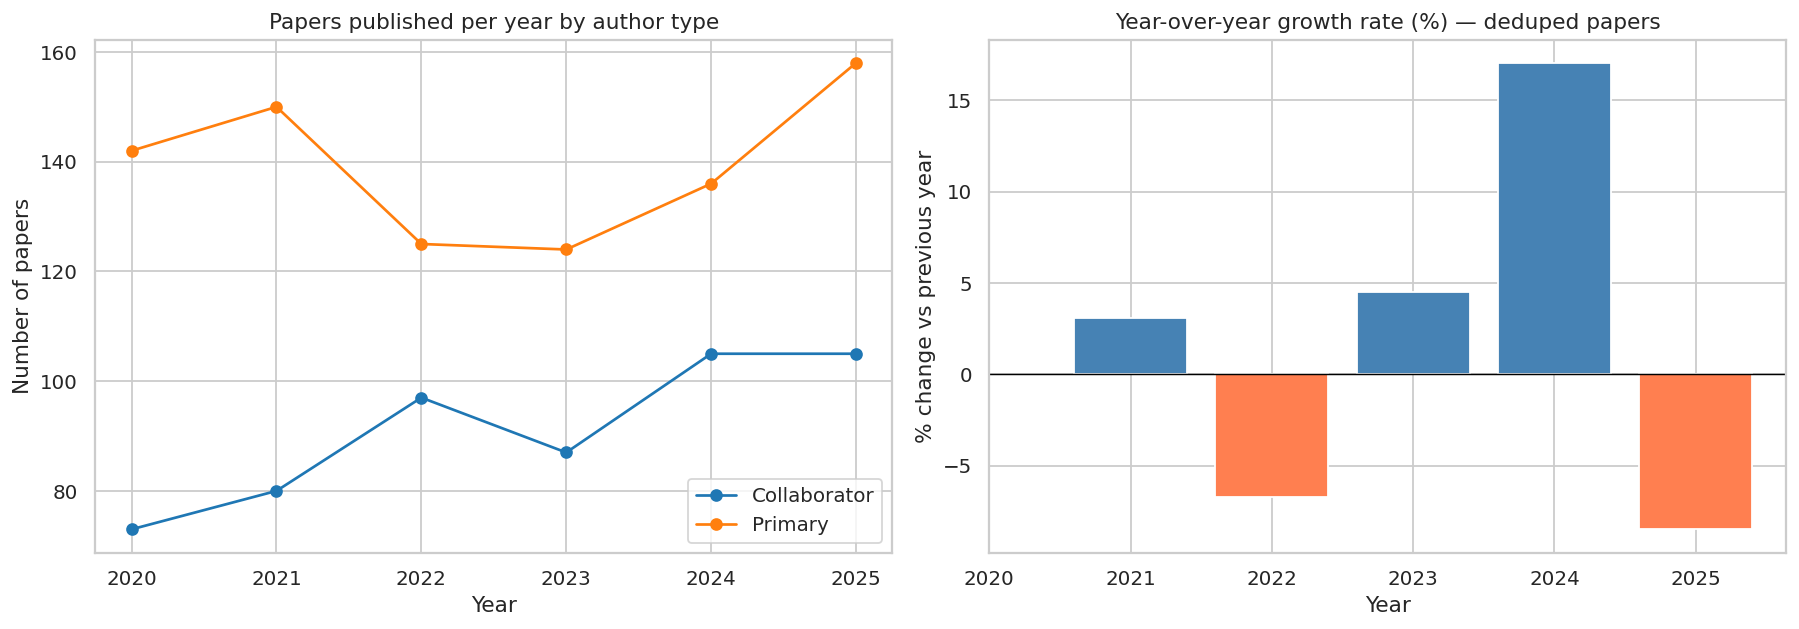

In [480]:
# ── Papers per year — split by author type ────────────────────────────────────
yearly = (
    filtered_df_dedup
    .dropna(subset=["publication_year"])
    .groupby(["publication_year", "author_type"])
    .size()
    .reset_index(name="n_papers")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for author_type, grp in yearly.groupby("author_type"):
    axes[0].plot(grp["publication_year"], grp["n_papers"], marker="o", label=author_type)
axes[0].set_title("Papers published per year by author type")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of papers")
axes[0].legend()
axes[0].set_xticks(sorted(yearly["publication_year"].unique()))

# Growth rate (deduped, all authors combined)
yearly_total = (
    all_df_dedup.dropna(subset=["publication_year"])
    .groupby("publication_year").size()
    .rename("n_papers")
    .reset_index()
    .sort_values("publication_year")
)
yearly_total["yoy_growth"] = yearly_total["n_papers"].pct_change() * 100

axes[1].bar(yearly_total["publication_year"], yearly_total["yoy_growth"],
            color=["coral" if v < 0 else "steelblue" for v in yearly_total["yoy_growth"]],
            edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Year-over-year growth rate (%) — deduped papers")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% change vs previous year")
axes[1].set_xticks(sorted(yearly_total["publication_year"].unique()))

plt.tight_layout()
plt.show()

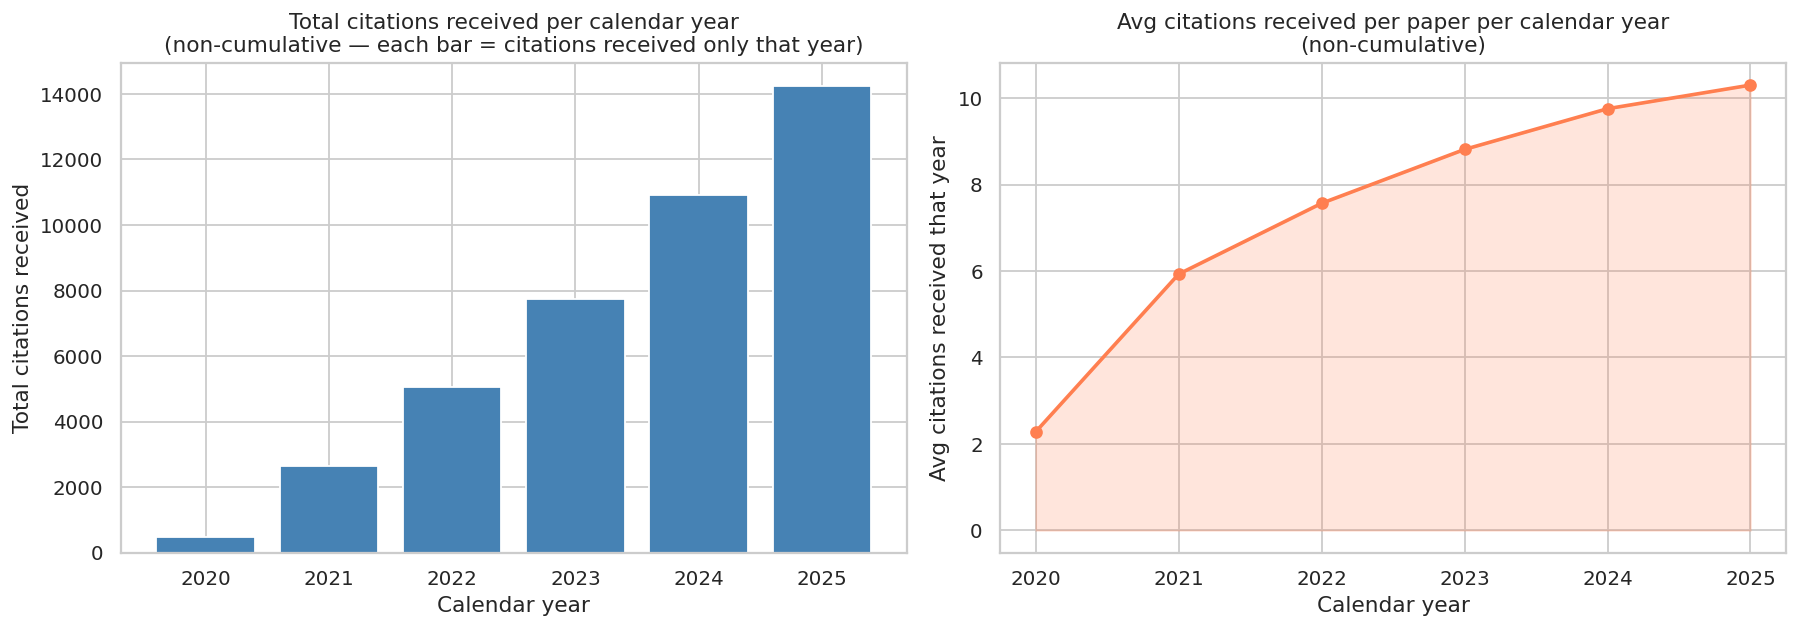

 calendar_year  total_cit   avg_cit    n
          2020      490.0  2.279070  215
          2021     2638.0  5.928090  445
          2022     5047.0  7.566717  667
          2023     7738.0  8.813212  878
          2024    10916.0  9.755139 1119
          2025    14237.0 10.301737 1382


In [481]:
# ── Citations received per calendar year (non-cumulative, deduped papers) ─────
# citations_year_k = citations received in (publication_year + k).
# We convert offsets → calendar years so each data point = citations
# received only in that specific year (not accumulated over all time).

cit_year_cols = [c for c in filtered_df_dedup.columns if c.startswith("citations_year_")]

melted = (
    filtered_df_dedup
    .dropna(subset=["publication_year"])
    [["article_id", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted["offset"]        = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"]     = melted["citations"].fillna(0)

# Keep only complete past calendar years
melted = melted[(melted["calendar_year"] >= 2020) & (melted["calendar_year"] <= CURRENT_YEAR - 1)]

cit_yearly = (
    melted.groupby("calendar_year")
    .agg(total_cit=("citations", "sum"),
         avg_cit=("citations", "mean"),
         n=("article_id", "nunique"))
    .reset_index()
    .sort_values("calendar_year")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cit_yearly["calendar_year"], cit_yearly["total_cit"],
            color="steelblue", edgecolor="white")
axes[0].set_title("Total citations received per calendar year\n(non-cumulative — each bar = citations received only that year)")
axes[0].set_xlabel("Calendar year")
axes[0].set_ylabel("Total citations received")
axes[0].set_xticks(cit_yearly["calendar_year"])

axes[1].plot(cit_yearly["calendar_year"], cit_yearly["avg_cit"],
             marker="o", color="coral", linewidth=2)
axes[1].fill_between(cit_yearly["calendar_year"], cit_yearly["avg_cit"],
                     alpha=0.2, color="coral")
axes[1].set_title("Avg citations received per paper per calendar year\n(non-cumulative)")
axes[1].set_xlabel("Calendar year")
axes[1].set_ylabel("Avg citations received that year")
axes[1].set_xticks(cit_yearly["calendar_year"])

plt.tight_layout()
plt.show()
print(cit_yearly.to_string(index=False))


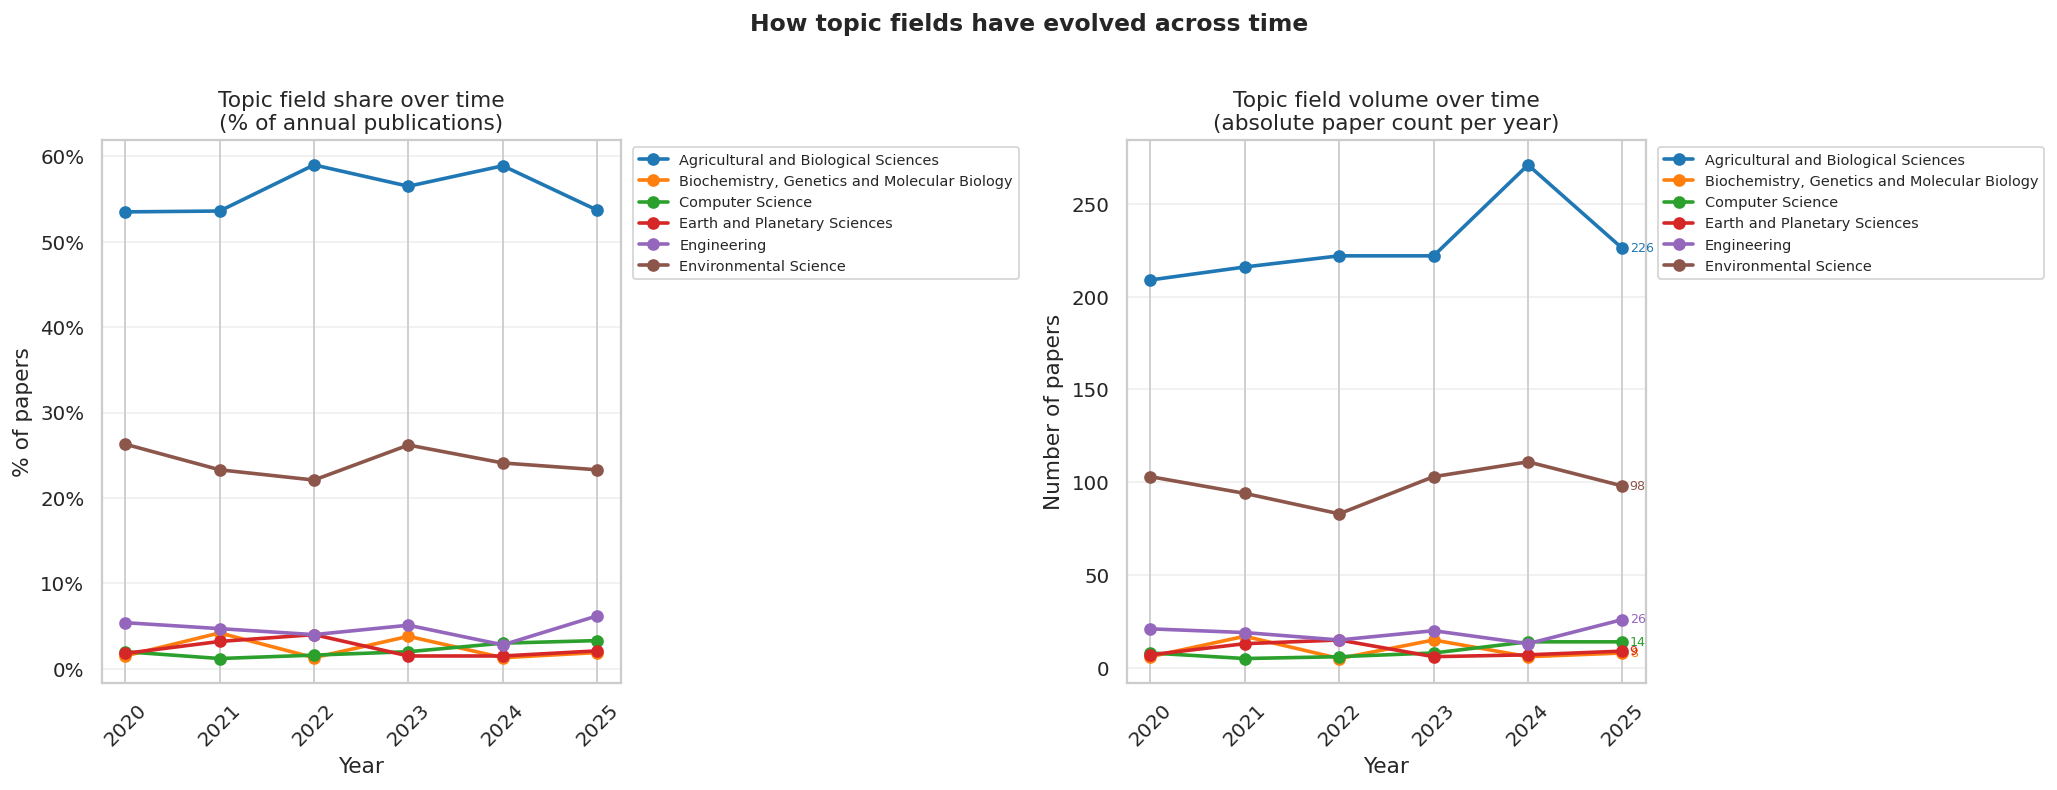


Most common primary topic per year:
 publication_year                             top_topic  n_papers
             2020 Climate change impacts on agriculture        47
             2021 Climate change impacts on agriculture        51
             2022 Climate change impacts on agriculture        38
             2023 Climate change impacts on agriculture        38
             2024         Crop Yield and Soil Fertility        46
             2025 Climate change impacts on agriculture        38


In [482]:

# ── Topic field presence across time ─────────────────────────────────────────
topic_yearly_counts = (
    all_df_dedup
    .dropna(subset=["primary_topic", "publication_year"])
    .groupby(["publication_year", "primary_topic"])
    .size()
    .reset_index(name="n_papers")
    .sort_values(["publication_year", "n_papers"], ascending=[True, False])
)

# Top topic per year
top_topic_per_year = (
    topic_yearly_counts
    .groupby("publication_year")
    .first()
    .reset_index()[["publication_year", "primary_topic", "n_papers"]]
    .rename(columns={"primary_topic": "top_topic"})
)

# Topic field counts and % per year (top 6 fields)
top6_fields = (
    all_df_dedup.dropna(subset=["topic_field"])
    .groupby("topic_field")["article_id"].count()
    .nlargest(6).index.tolist()
)

field_yr = (
    all_df_dedup
    .dropna(subset=["topic_field", "publication_year"])
    .query("topic_field in @top6_fields")
    .groupby(["publication_year", "topic_field"])
    .size()
    .reset_index(name="n")
)
total_per_yr = (
    all_df_dedup.dropna(subset=["publication_year"])
    .groupby("publication_year")["article_id"].count()
    .rename("total")
)
field_yr = field_yr.merge(total_per_yr.reset_index(), on="publication_year")
field_yr["pct"] = (field_yr["n"] / field_yr["total"] * 100).round(1)

sorted_years = sorted(all_df_dedup["publication_year"].dropna().unique())
colors_list = plt.get_cmap("tab10").colors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: % share over time
for i, (field, grp) in enumerate(field_yr.groupby("topic_field")):
    grp = grp.sort_values("publication_year")
    axes[0].plot(grp["publication_year"], grp["pct"],
                 marker="o", linewidth=2, label=field, color=colors_list[i % 10])
axes[0].set_title("Topic field share over time\n(% of annual publications)", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% of papers")
axes[0].set_xticks(sorted_years)
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Right: absolute paper count over time
for i, (field, grp) in enumerate(field_yr.groupby("topic_field")):
    grp = grp.sort_values("publication_year")
    axes[1].plot(grp["publication_year"], grp["n"],
                 marker="o", linewidth=2, label=field, color=colors_list[i % 10])
    # Annotate last data point
    last = grp.iloc[-1]
    axes[1].annotate(
        f"{int(last['n'])}",
        xy=(last["publication_year"], last["n"]),
        xytext=(4, 0), textcoords="offset points",
        fontsize=7, va="center", color=colors_list[i % 10]
    )
axes[1].set_title("Topic field volume over time\n(absolute paper count per year)", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of papers")
axes[1].set_xticks(sorted_years)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("How topic fields have evolved across time", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nMost common primary topic per year:")
print(top_topic_per_year.to_string(index=False))


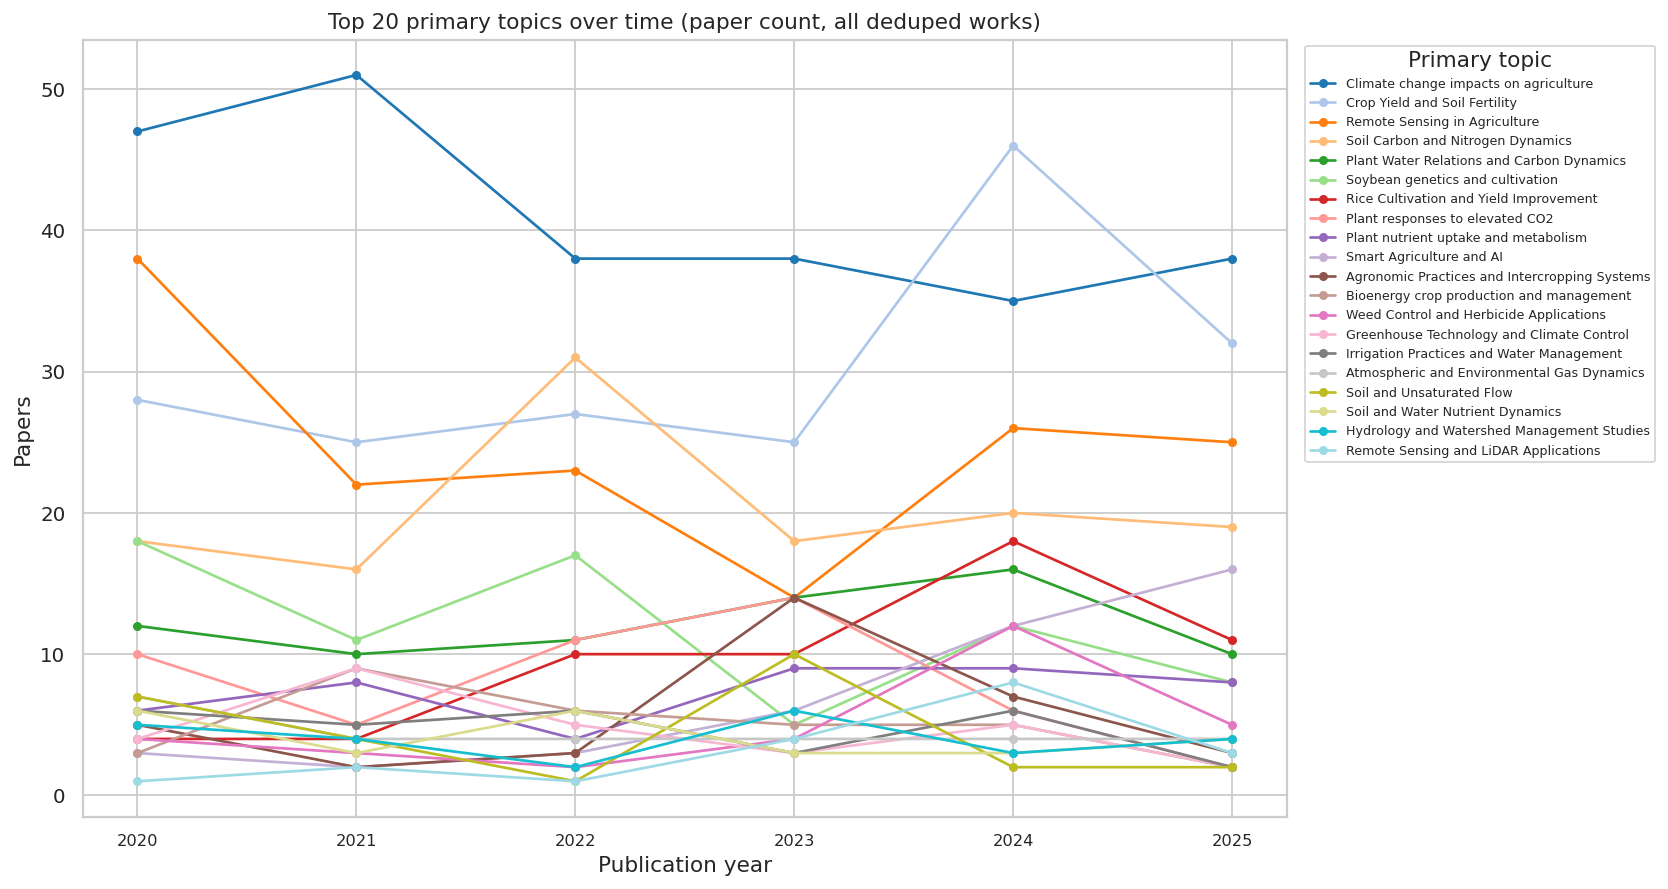

In [483]:

# ── Top primary topics × year line plot (absolute counts) ─────────────────────
top20_topics = (
    all_df_dedup.dropna(subset=["primary_topic"])
    .groupby("primary_topic")["article_id"].count()
    .nlargest(20).index.tolist()
)

topic_yr_pivot = (
    all_df_dedup
    .dropna(subset=["primary_topic", "publication_year"])
    .query("primary_topic in @top20_topics")
    .groupby(["primary_topic", "publication_year"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        all_df_dedup.dropna(subset=["primary_topic"])
        .groupby("primary_topic")["article_id"].count()
        .reindex(top20_topics)
        .sort_values(ascending=False).index
    )
)

fig, ax = plt.subplots(figsize=(13, 7))
cmap_lines = plt.get_cmap("tab20")
for i, topic in enumerate(topic_yr_pivot.index):
    ax.plot(
        topic_yr_pivot.columns,
        topic_yr_pivot.loc[topic],
        marker="o", markersize=4,
        linewidth=1.5,
        color=cmap_lines(i / len(topic_yr_pivot)),
        label=topic
    )
ax.set_title("Top 20 primary topics over time (paper count, all deduped works)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers")
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.legend(title="Primary topic", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


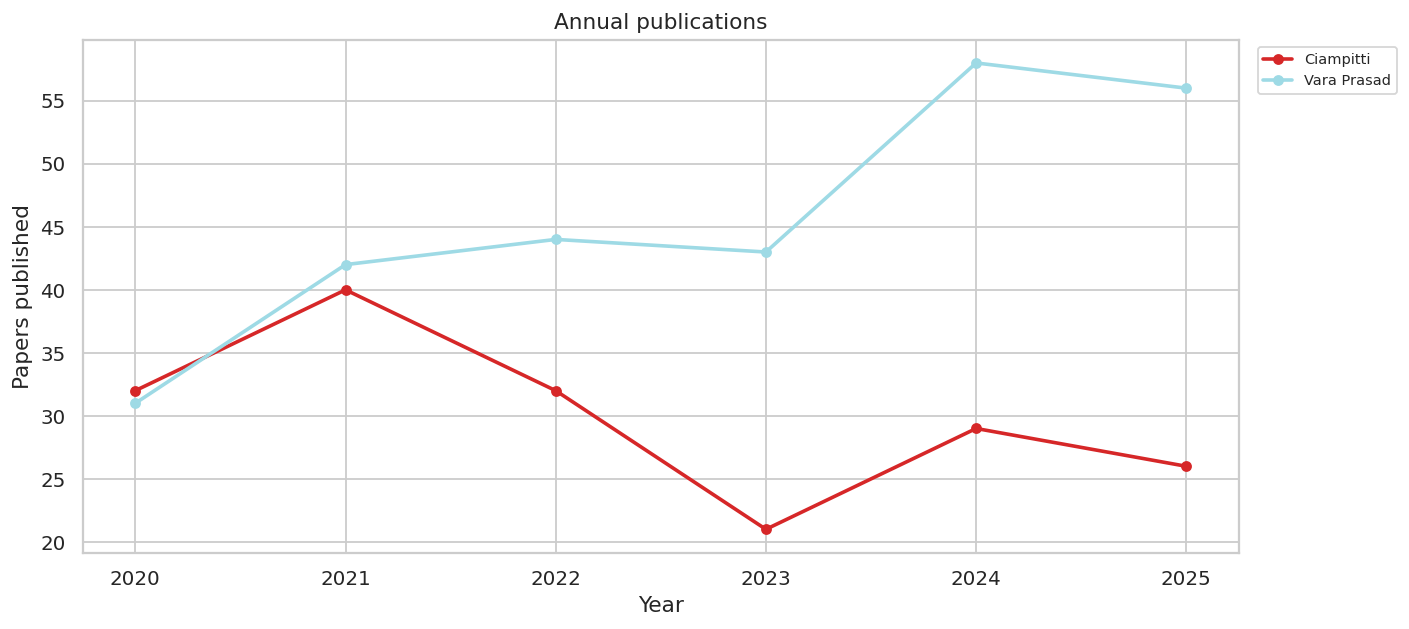

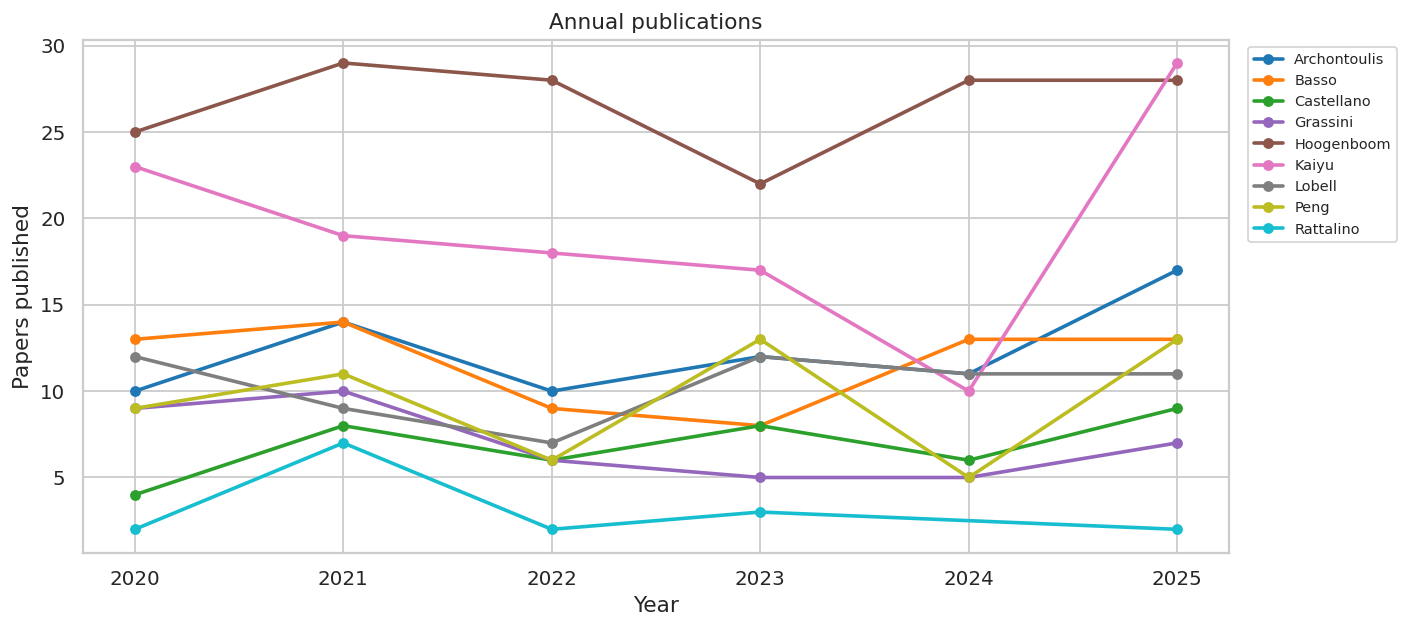

Most prolific primary author each year:
 publication_year  top_author  papers
             2020   Ciampitti      32
             2021 Vara Prasad      42
             2022 Vara Prasad      44
             2023 Vara Prasad      43
             2024 Vara Prasad      58
             2025 Vara Prasad      56


In [484]:

# ── Annual publications per primary author – line plots by productivity group ──
author_yearly = (
    primary_filtered_dedup
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year"])
    .size()
    .reset_index(name="n_papers")
)

# Most prolific author each year
yearly_leader = (
    author_yearly
    .sort_values("n_papers", ascending=False)
    .groupby("publication_year")
    .first()
    .reset_index()[["publication_year", "queried_author", "n_papers"]]
    .rename(columns={"queried_author": "top_author", "n_papers": "papers"})
)

# Split authors: "high output" = >30 papers in at least 2 years
years_above_30 = (
    author_yearly[author_yearly["n_papers"] > 30]
    .groupby("queried_author")
    .size()
)
high_output = years_above_30[years_above_30 >= 2].index.tolist()
low_output  = [a for a in author_yearly["queried_author"].unique() if a not in high_output]

cmap_all = plt.get_cmap("tab20")
all_authors = sorted(author_yearly["queried_author"].unique())
author_colors = {a: cmap_all(i / max(len(all_authors) - 1, 1)) for i, a in enumerate(all_authors)}

for group_label, group_authors in [
    ("High-output authors (>30 papers in ≥2 years)", high_output),
    ("Other authors", low_output),
]:
    if not group_authors:
        continue
    fig, ax = plt.subplots(figsize=(11, 5))
    for author in group_authors:
        grp = author_yearly[author_yearly["queried_author"] == author]
        ax.plot(
            grp["publication_year"], grp["n_papers"],
            marker="o", linewidth=2, markersize=5,
            color=author_colors[author], label=author
        )
    ax.set_title(f"Annual publications")
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers published")
    ax.set_xticks(sorted(primary_filtered_dedup["publication_year"].dropna().unique()))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

print("Most prolific primary author each year:")
print(yearly_leader.to_string(index=False))


---
## 9. Co-authorship Network Overview
How frequently do the primary authors collaborate with each other? We extract co-author pairs from the raw `authorships` field and build a collaboration frequency matrix.

In [485]:
# ── Build co-authorship frequency matrix among primary authors ────────────────
primary_aid_to_name = {aid: name for aid, name in author_ids.items()}
primary_names = sorted(author_ids.values())

coauth_matrix = pd.DataFrame(0, index=primary_names, columns=primary_names)

for work in primary_works:
    # All primary author IDs on this paper
    present_primaries = [
        primary_aid_to_name[auth["author"]["id"]]
        for auth in work.get("authorships", [])
        if auth.get("author", {}).get("id") in primary_aid_to_name
    ]
    # For every pair, increment
    for i, a in enumerate(present_primaries):
        for b in present_primaries[i + 1:]:
            coauth_matrix.loc[a, b] += 1
            coauth_matrix.loc[b, a] += 1

print("Co-authorship frequency matrix (primary authors only):\n")
print(coauth_matrix.to_string())

Co-authorship frequency matrix (primary authors only):

              Archontoulis  Basso  Castellano  Ciampitti  Grassini  Hoogenboom  Kaiyu  Lobell  Peng  Rattalino  Vara Prasad
Archontoulis             0     33          58         17        16          47     36       8    36          9            0
Basso                   33      0           3          0         0          61     32       0    25          0            0
Castellano              58      3           0          7         7           0      3       0     0          0            0
Ciampitti               17      0           7          2         7           0      6       0     3          3          197
Grassini                16      0           7          7         0           0      0       0     0         58            0
Hoogenboom              47     61           0          0         0           0     41       0    33          0            0
Kaiyu                   36     32           3          6         0          

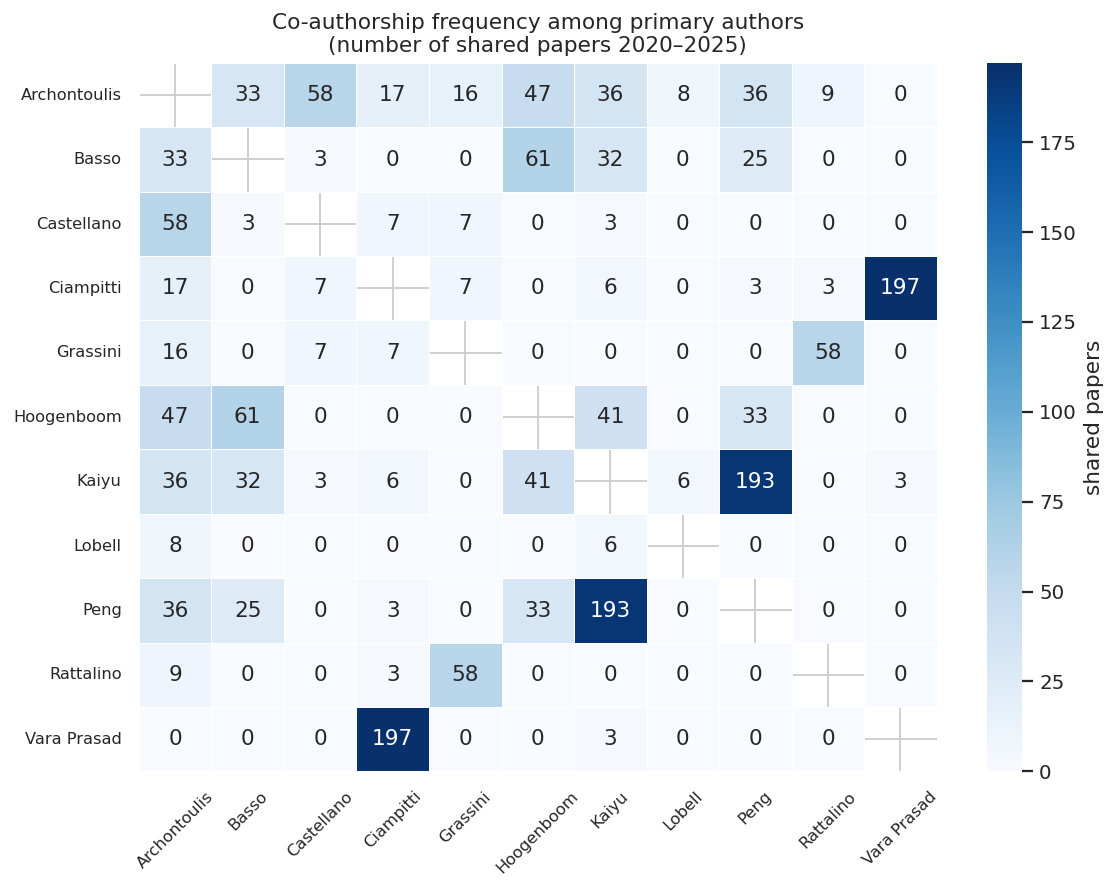

In [486]:
# ── Co-authorship heatmap ─────────────────────────────────────────────────────
mask_diag = np.eye(len(coauth_matrix), dtype=bool)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    coauth_matrix,
    mask=mask_diag,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "shared papers"},
    ax=ax,
)
ax.set_title("Co-authorship frequency among primary authors\n(number of shared papers 2020–2025)")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

In [487]:
# ── Network graph of co-authorship (networkx) ─────────────────────────────────
try:
    import networkx as nx

    G = nx.Graph()
    G.add_nodes_from(primary_names)

    for i, a in enumerate(primary_names):
        for j, b in enumerate(primary_names):
            if i < j and coauth_matrix.loc[a, b] > 0:
                G.add_edge(a, b, weight=int(coauth_matrix.loc[a, b]))

    # Node size ∝ total papers
    node_sizes = {
        name: primary_df[primary_df["queried_author"] == name]["article_id"].nunique()
        for name in primary_names
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=1.5)

    nx.draw_networkx_nodes(
        G, pos,
        node_size=[node_sizes.get(n, 10) * 15 for n in G.nodes()],
        node_color="steelblue", alpha=0.85, ax=ax,
    )
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_edges(
        G, pos,
        width=[w * 0.8 for w in edge_weights],
        edge_color="gray", alpha=0.7, ax=ax,
    )
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    # Edge labels (weight)
    edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges() if G[u][v]["weight"] > 1}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    ax.set_title("Co-authorship network — primary authors\n(node size ∝ papers, edge width ∝ shared papers)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("networkx not installed. Run: pip install networkx")
    print("Showing the matrix table instead:")
    print(coauth_matrix.to_string())

networkx not installed. Run: pip install networkx
Showing the matrix table instead:
              Archontoulis  Basso  Castellano  Ciampitti  Grassini  Hoogenboom  Kaiyu  Lobell  Peng  Rattalino  Vara Prasad
Archontoulis             0     33          58         17        16          47     36       8    36          9            0
Basso                   33      0           3          0         0          61     32       0    25          0            0
Castellano              58      3           0          7         7           0      3       0     0          0            0
Ciampitti               17      0           7          2         7           0      6       0     3          3          197
Grassini                16      0           7          7         0           0      0       0     0         58            0
Hoogenboom              47     61           0          0         0           0     41       0    33          0            0
Kaiyu                   36     32           3   

---
## Summary & Next Steps

### What this EDA covered
| Section | Key questions answered |
|---|---|
| API structure | What fields OpenAlex returns and their completeness |
| Publications DF | Shape, types, missing values |
| Citations | Distribution skew, top papers, accumulation speed, OA vs citation lift |
| Authors | Productivity, role breakdown, corresponding-author impact |
| Journals | Publication volume, 2-year citation velocity, OA mix |
| Concepts | Dominant research themes (crop yield, soil, modeling, remote sensing…) and their co-occurrence |
| Temporal | Year-by-year growth, cohort citation curves |
| Network | Which authors collaborate and how intensely |

### Suggested next steps
- **Topic modeling (LDA / BERTopic)** — cluster papers by title/abstract semantics  
- **Abstract-level text analysis** — keyword frequency, n-grams, emerging terms  
- **Field-level benchmarking** — compare these authors to the broader agronomy literature  
- **Citation network** — who cites whom, identify bridge papers  
- **Journal submission strategy** — gap analysis between where authors publish and where high-impact work appears